In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_name = '/content/National_Achievement_Survey_dataset.csv'

try:
    df = pd.read_csv(file_name)
    print(f"Successfully loaded '{file_name}'. It has {df.shape[0]} rows.")
except FileNotFoundError:
    print(f"ERROR: The file '{file_name}' was not found. Please upload it and check the name.")

# See the first 5 rows
df.head()

Successfully loaded '/content/National_Achievement_Survey_dataset.csv'. It has 1405 rows.


,Country,State,District,Year,Class,"Number Of Schools Surveyed (UOM:Number), Scaling Factor:1","Number Of Students Surveyed (UOM:Number), Scaling Factor:1","Average Performance Of Students In L813 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1","Average Performance Of Students In M601 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1","Average Performance Of Students In M606 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1",...,"Average Performance Of Students In Sst807 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1","Average Performance Of Students In Sst809 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1","Average Performance Of Students In Sst810 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1","Average Performance Of Students In Sst815 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1","Average Performance Of Students In Sst816 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1","Average Performance Of Students In Sst818 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1","Average Performance Of Students In Sst823 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1","Average Performance Of Students In Sst827 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1","Average Performance Of Students In Sst831 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1","Average Performance Of Students In Sst833 Learning Outcome (UOM:%(Percentage)), Scaling Factor:1"
0,India,Andaman and Nicobar Islands,Nicobars,"Calendar Year (Jan - Dec), 2021",8,80.0,1412.0,37.58,39.72,33.55,...,15.46,24.81,10.79,16.42,11.64,33.94,57.59,48.56,35.05,29.05
1,India,Andaman and Nicobar Islands,North and Middle Andaman,"Calendar Year (Jan - Dec), 2021",8,132.0,2428.0,50.02,47.57,43.83,...,33.16,36.51,23.13,33.29,34.94,43.87,24.33,31.76,26.19,56.51
2,India,Andaman and Nicobar Islands,South Andamans,"Calendar Year (Jan - Dec), 2021",8,188.0,4588.0,57.06,53.56,45.73,...,35.39,36.60,17.93,29.83,30.16,35.41,28.70,26.91,30.60,62.92
3,India,Andhra Pradesh,Ananthapuramu,"Calendar Year (Jan - Dec), 2021",8,264.0,7000.0,47.09,45.60,44.65,...,34.64,29.59,24.51,26.15,25.23,36.17,39.94,28.80,32.78,59.06
4,India,Andhra Pradesh,East Godavari,"Calendar Year (Jan - Dec), 2021",8,216.0,5736.0,48.83,43.50,47.11,...,39.76,32.18,21.34,25.52,23.47,35.21,35.75,26.63,35.42,60.91


In [ ]:
# --- 2.1: Clean Column Names ---
# This function makes column names shorter and easier to use in code
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.split('(')[0].strip().replace(' ', '_')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

df = clean_col_names(df)
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})').astype(int)

# --- 2.2: Create Summary Scores for Subjects ---
# We calculate an average score for Math, Science, and Social Studies (SST)
math_cols = [col for col in df.columns if '_In_M' in col]
science_cols = [col for col in df.columns if '_In_Sci' in col]
sst_cols = [col for col in df.columns if '_In_Sst' in col]
language_cols = [col for col in df.columns if '_In_L' in col] # Added language column

df['Math_Performance'] = df[math_cols].mean(axis=1)
df['Science_Performance'] = df[science_cols].mean(axis=1)
df['SST_Performance'] = df[sst_cols].mean(axis=1)
df['Language_Performance'] = df[language_cols].mean(axis=1) # Added language performance
df['Overall_Performance'] = df[['Math_Performance', 'Science_Performance', 'SST_Performance', 'Language_Performance']].mean(axis=1) # Updated overall performance

# --- 2.3: Focus on the most recent year's data (2021) ---
df_2021 = df[df['Year'] == 2021].copy()

print("Data is now clean and summary scores have been created.")
# Display the new summary columns
df_2021[['State', 'District', 'Overall_Performance', 'Math_Performance', 'Science_Performance', 'Language_Performance']]

Data is now clean and summary scores have been created.


,State,District,Overall_Performance,Math_Performance,Science_Performance,Language_Performance
0,Andaman and Nicobar Islands,Nicobars,31.142640,31.4395,26.298333,37.58
1,Andaman and Nicobar Islands,North and Middle Andaman,39.627515,33.3290,39.883333,50.02
2,Andaman and Nicobar Islands,South Andamans,42.256182,34.3445,41.162500,57.06
3,Andhra Pradesh,Ananthapuramu,37.178542,35.7450,33.019167,47.09
4,Andhra Pradesh,East Godavari,38.376511,35.8615,34.795000,48.83
...,...,...,...,...,...,...
703,West Bengal,Purba Bardhaman,44.882841,35.3100,42.040000,59.70
704,West Bengal,Purba Medinipur,48.344519,40.5655,45.801667,62.33
705,West Bengal,Purulia,37.471610,33.2150,35.134167,47.39
706,West Bengal,South 24 Parganas,44.106587,36.2465,41.311667,56.88


--- National Performance Summary (2021) ---
       Overall_Performance  Math_Performance  Science_Performance  \
count           706.000000        706.000000           706.000000   
mean             41.187490         35.926949            38.303162   
std               5.628479          6.422964             5.090959   
min              28.057402         24.211500            26.298333   
25%              37.271472         31.366250            34.759375   
50%              40.576742         35.014750            37.603333   
75%              44.161152         38.692250            41.190625   
max              67.569102         72.113000            60.727500   

       SST_Performance  
count       706.000000  
mean         38.045167  
std           5.040998  
min          27.198182  
25%          34.632614  
50%          37.393409  
75%          40.313523  
max          66.715909  


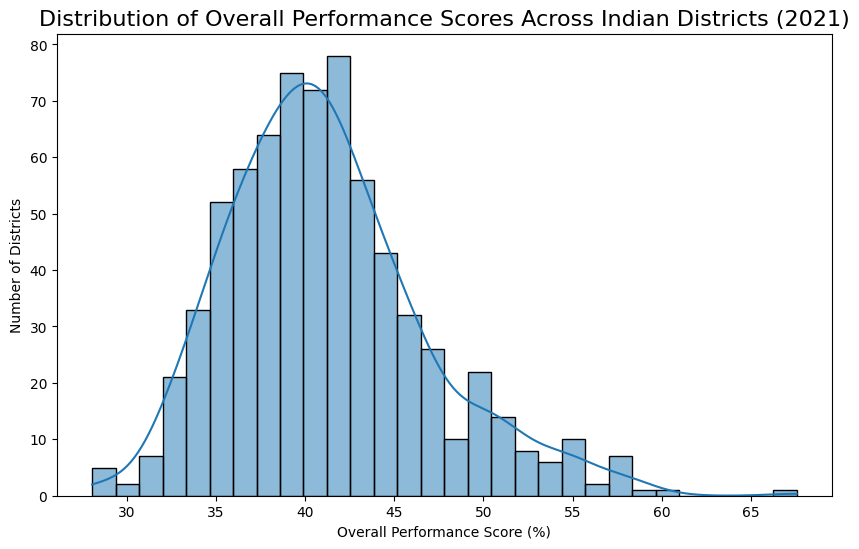

In [ ]:
# --- 3.1: See the national summary statistics ---
print("--- National Performance Summary (2021) ---")
# This shows the average, min, max, etc., for our summary scores across all districts
print(df_2021[['Overall_Performance', 'Math_Performance', 'Science_Performance', 'SST_Performance']].describe())


# --- 3.2: Visualize the distribution of scores ---
plt.figure(figsize=(10, 6))
sns.histplot(df_2021['Overall_Performance'], kde=True, bins=30)
plt.title('Distribution of Overall Performance Scores Across Indian Districts (2021)', fontsize=16)
plt.xlabel('Overall Performance Score (%)')
plt.ylabel('Number of Districts')
plt.show()

--- State Rankings by Average Overall Performance - Worst to Best ---
State
Punjab                                          53.500913
Chandigarh                                      51.827735
Rajasthan                                       49.711294
Haryana                                         47.583363
Ladakh                                          44.372116
Madhya Pradesh                                  43.914456
Jammu and Kashmir                               43.362097
West Bengal                                     43.209836
Delhi                                           42.955650
Goa                                             42.923991
Gujarat                                         42.831386
Maharashtra                                     42.168858
Uttarakhand                                     41.769217
Manipur                                         41.760042
Himachal Pradesh                                41.691873
Odisha                                          41.323

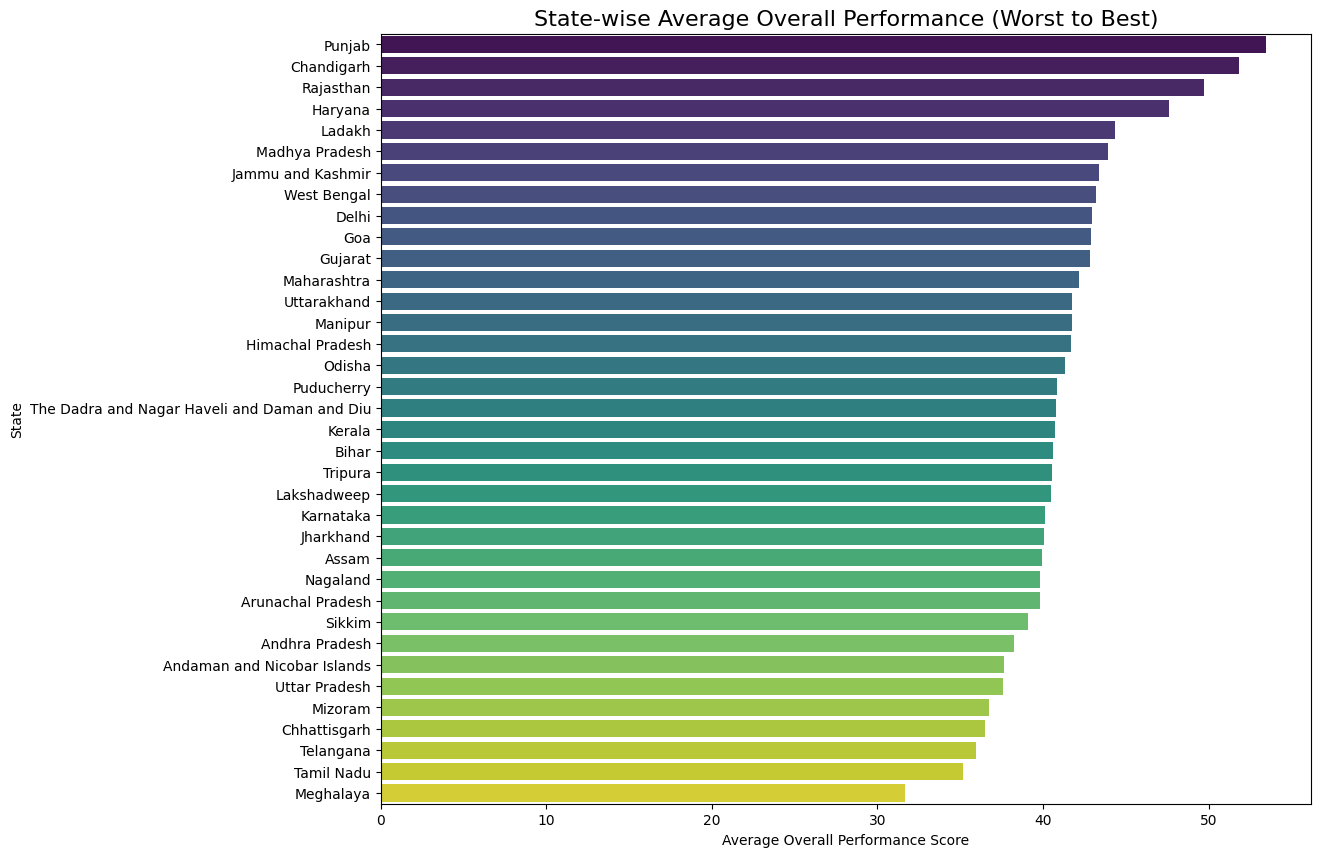

In [ ]:
# --- 4.1: Calculate average performance for each state ---
state_performance = df_2021.groupby('State')['Overall_Performance'].mean().sort_values(ascending=False)

print("--- State Rankings by Average Overall Performance - Worst to Best ---")
print(state_performance)

# --- 4.2: Create a bar chart to visualize state rankings ---
plt.figure(figsize=(12, 10))
sns.barplot(x=state_performance.values, y=state_performance.index, palette='viridis', hue=state_performance.index, legend=False)
plt.title('State-wise Average Overall Performance (Worst to Best)', fontsize=16)
plt.xlabel('Average Overall Performance Score')
plt.ylabel('State')
plt.show()

--- Top 10 Most Difficult Topics Nationally (Lowest Average Score) ---
M705      22.385850
Sst610    26.116657
Sci711    26.259915
Sst810    27.169533
Sst816    27.474398
M706      28.044292
M620      28.323265
Sst805    28.661197
M710      29.167252
M819      29.681558
dtype: float64


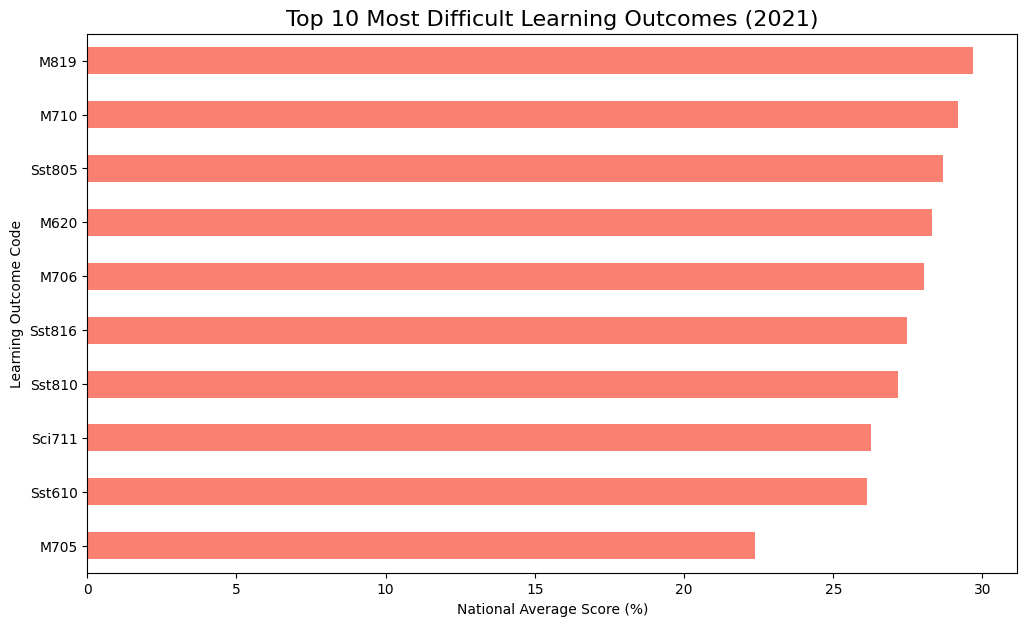

In [ ]:
# --- 5.1: Find the average score for every single learning outcome ---
# We will use the original columns for this
learning_outcome_cols = [col for col in df.columns if col.startswith('Average_Performance')]
topic_performance = df_2021[learning_outcome_cols].mean().sort_values(ascending=True)

# --- 5.2: Identify and plot the 10 most difficult topics ---
hardest_topics = topic_performance.head(10)
# Clean up the names for the plot
hardest_topics.index = hardest_topics.index.str.replace('Average_Performance_Of_Students_In_', '').str.replace('_Learning_Outcome', '')

print("--- Top 10 Most Difficult Topics Nationally (Lowest Average Score) ---")
print(hardest_topics)

# --- 5.3: Create a bar chart for the hardest topics ---
plt.figure(figsize=(12, 7))
hardest_topics.plot(kind='barh', color='salmon')
plt.title('Top 10 Most Difficult Learning Outcomes (2021)', fontsize=16)
plt.xlabel('National Average Score (%)')
plt.ylabel('Learning Outcome Code')
plt.show()

--- Correlation Matrix Between Subjects ---
                     Math_Performance  Science_Performance  SST_Performance
Math_Performance             1.000000             0.852117         0.907612
Science_Performance          0.852117             1.000000         0.924590
SST_Performance              0.907612             0.924590         1.000000


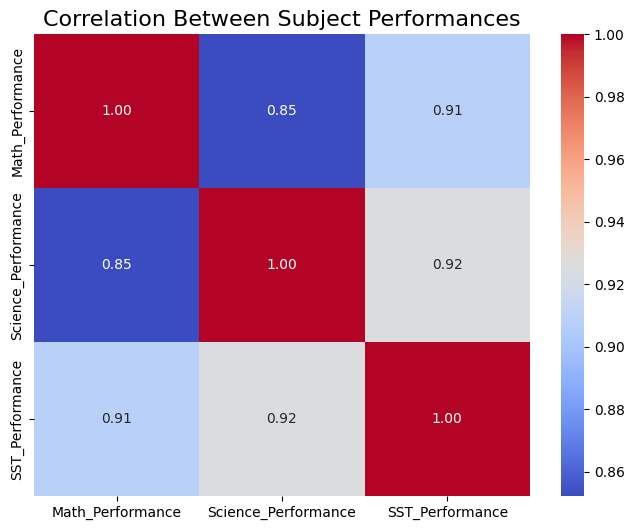

In [ ]:
# --- 7.1: Select the performance columns ---
subject_corr_df = df_2021[['Math_Performance', 'Science_Performance', 'SST_Performance']]

# --- 7.2: Calculate the correlation matrix ---
correlation_matrix = subject_corr_df.corr()

print("--- Correlation Matrix Between Subjects ---")
print(correlation_matrix)

# --- 7.3: Visualize the matrix as a heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Subject Performances', fontsize=16)
plt.show()

Found 16 districts with performance > 55%
--- Sample of High-Performing 'Bright Spot' Districts ---
              State   District  Overall_Performance
507       Rajasthan    Dholpur            67.569102
312  Madhya Pradesh      Bhind            59.704936
475          Punjab   Bathinda            58.810489
519       Rajasthan     Nagaur            58.070720
515       Rajasthan  Jhunjhunu            58.041432

Found 5 districts with performance < 30%
--- Sample of Low-Performing 'Hotspot' Districts ---
         State               District  Overall_Performance
409  Meghalaya        East Garo Hills            28.057402
412  Meghalaya       North Garo Hills            28.341277
414  Meghalaya       South Garo Hills            28.496841
419  Meghalaya       West Khasi Hills            28.695905
415  Meghalaya  South West Garo Hills            29.300311


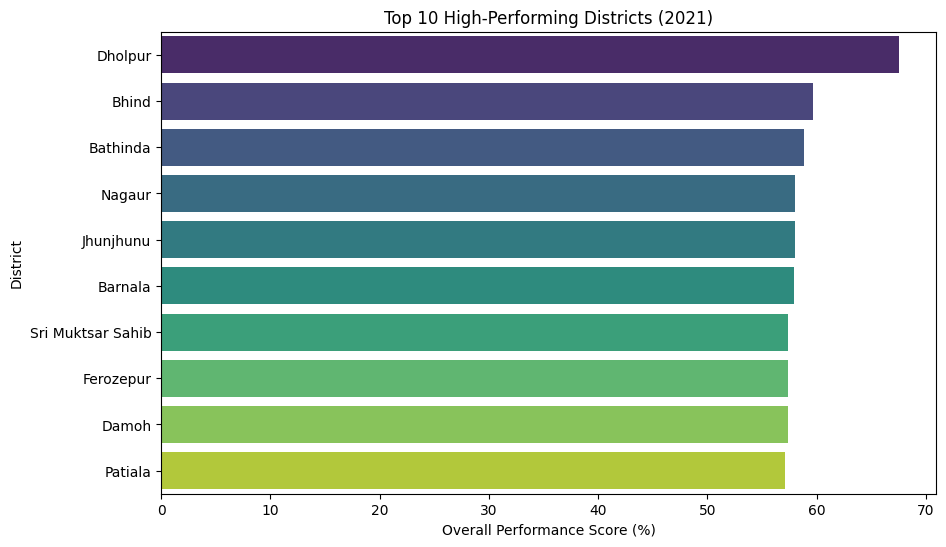

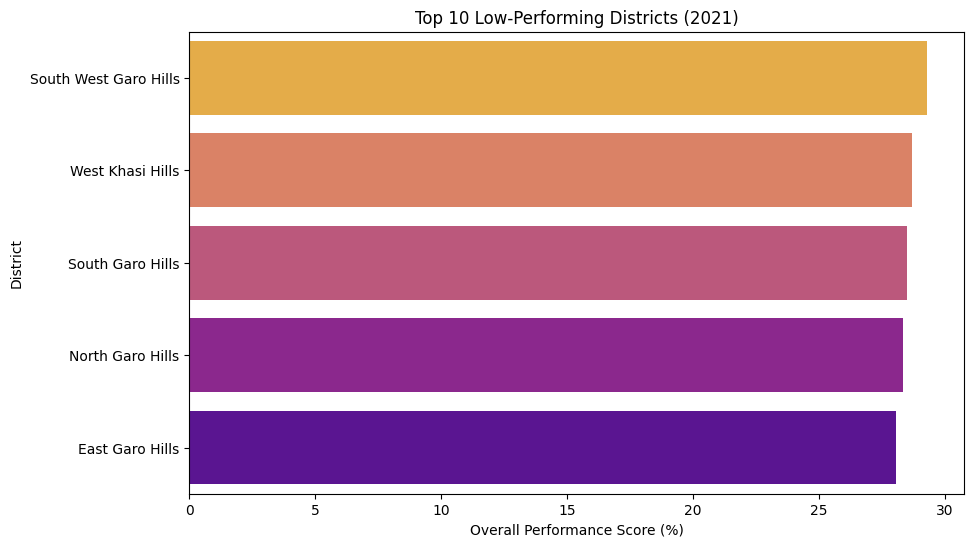

In [ ]:
# --- 8.1: Set performance thresholds ---
high_threshold = 55
low_threshold = 30

# --- 8.2: Filter the dataframe to find these districts ---
high_performing_districts = df_2021[df_2021['Overall_Performance'] > high_threshold].sort_values(by='Overall_Performance', ascending=False)
low_performing_districts = df_2021[df_2021['Overall_Performance'] < low_threshold].sort_values(by='Overall_Performance', ascending=True)

print(f"Found {len(high_performing_districts)} districts with performance > {high_threshold}%")
print("--- Sample of High-Performing 'Bright Spot' Districts ---")
print(high_performing_districts[['State', 'District', 'Overall_Performance']].head())

print(f"\nFound {len(low_performing_districts)} districts with performance < {low_threshold}%")
print("--- Sample of Low-Performing 'Hotspot' Districts ---")
print(low_performing_districts[['State', 'District', 'Overall_Performance']].head())

# --- 8.3: Visualize high-performing districts ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Overall_Performance', y='District', data=high_performing_districts.head(10), palette='viridis', hue='District', legend=False)
plt.title('Top 10 High-Performing Districts (2021)')
plt.xlabel('Overall Performance Score (%)')
plt.ylabel('District')
plt.show()

# --- 8.4: Visualize low-performing districts ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Overall_Performance', y='District', data=low_performing_districts.head(10), palette='plasma', hue='District', legend=False)
plt.title('Top 10 Low-Performing Districts (2021)')
plt.xlabel('Overall Performance Score (%)')
plt.ylabel('District')
plt.gca().invert_yaxis() # Invert the y-axis to show lowest performance at the top
plt.show()

In [ ]:
# --- 10.1: Calculate the performance gap for each topic ---
# A gap of 100% means an average score of 0%, and a gap of 0% means an average score of 100%
df_pareto = pd.DataFrame(topic_performance)
df_pareto.columns = ['average_score']
df_pareto['gap'] = 100 - df_pareto['average_score']

# --- 10.2: Sort by gap and calculate cumulative percentage ---
# To create a Pareto chart, we need the gaps sorted in descending order and the cumulative percentage
df_pareto = df_pareto.sort_values(by='gap', ascending=False)
df_pareto['cumulative_percentage'] = df_pareto['gap'].cumsum() / df_pareto['gap'].sum() * 100

print("--- Pareto Data Preparation Complete ---")
print(df_pareto[['gap', 'cumulative_percentage']].head())

--- Pareto Data Preparation Complete ---
                                                          gap  \
Average_Performance_Of_Students_In_M705_Learnin...  77.614150   
Average_Performance_Of_Students_In_Sst610_Learn...  73.883343   
Average_Performance_Of_Students_In_Sci711_Learn...  73.740085   
Average_Performance_Of_Students_In_Sst810_Learn...  72.830467   
Average_Performance_Of_Students_In_Sst816_Learn...  72.525602   

                                                    cumulative_percentage  
Average_Performance_Of_Students_In_M705_Learnin...               2.261251  
Average_Performance_Of_Students_In_Sst610_Learn...               4.413806  
Average_Performance_Of_Students_In_Sci711_Learn...               6.562188  
Average_Performance_Of_Students_In_Sst810_Learn...               8.684069  
Average_Performance_Of_Students_In_Sst816_Learn...              10.797067  


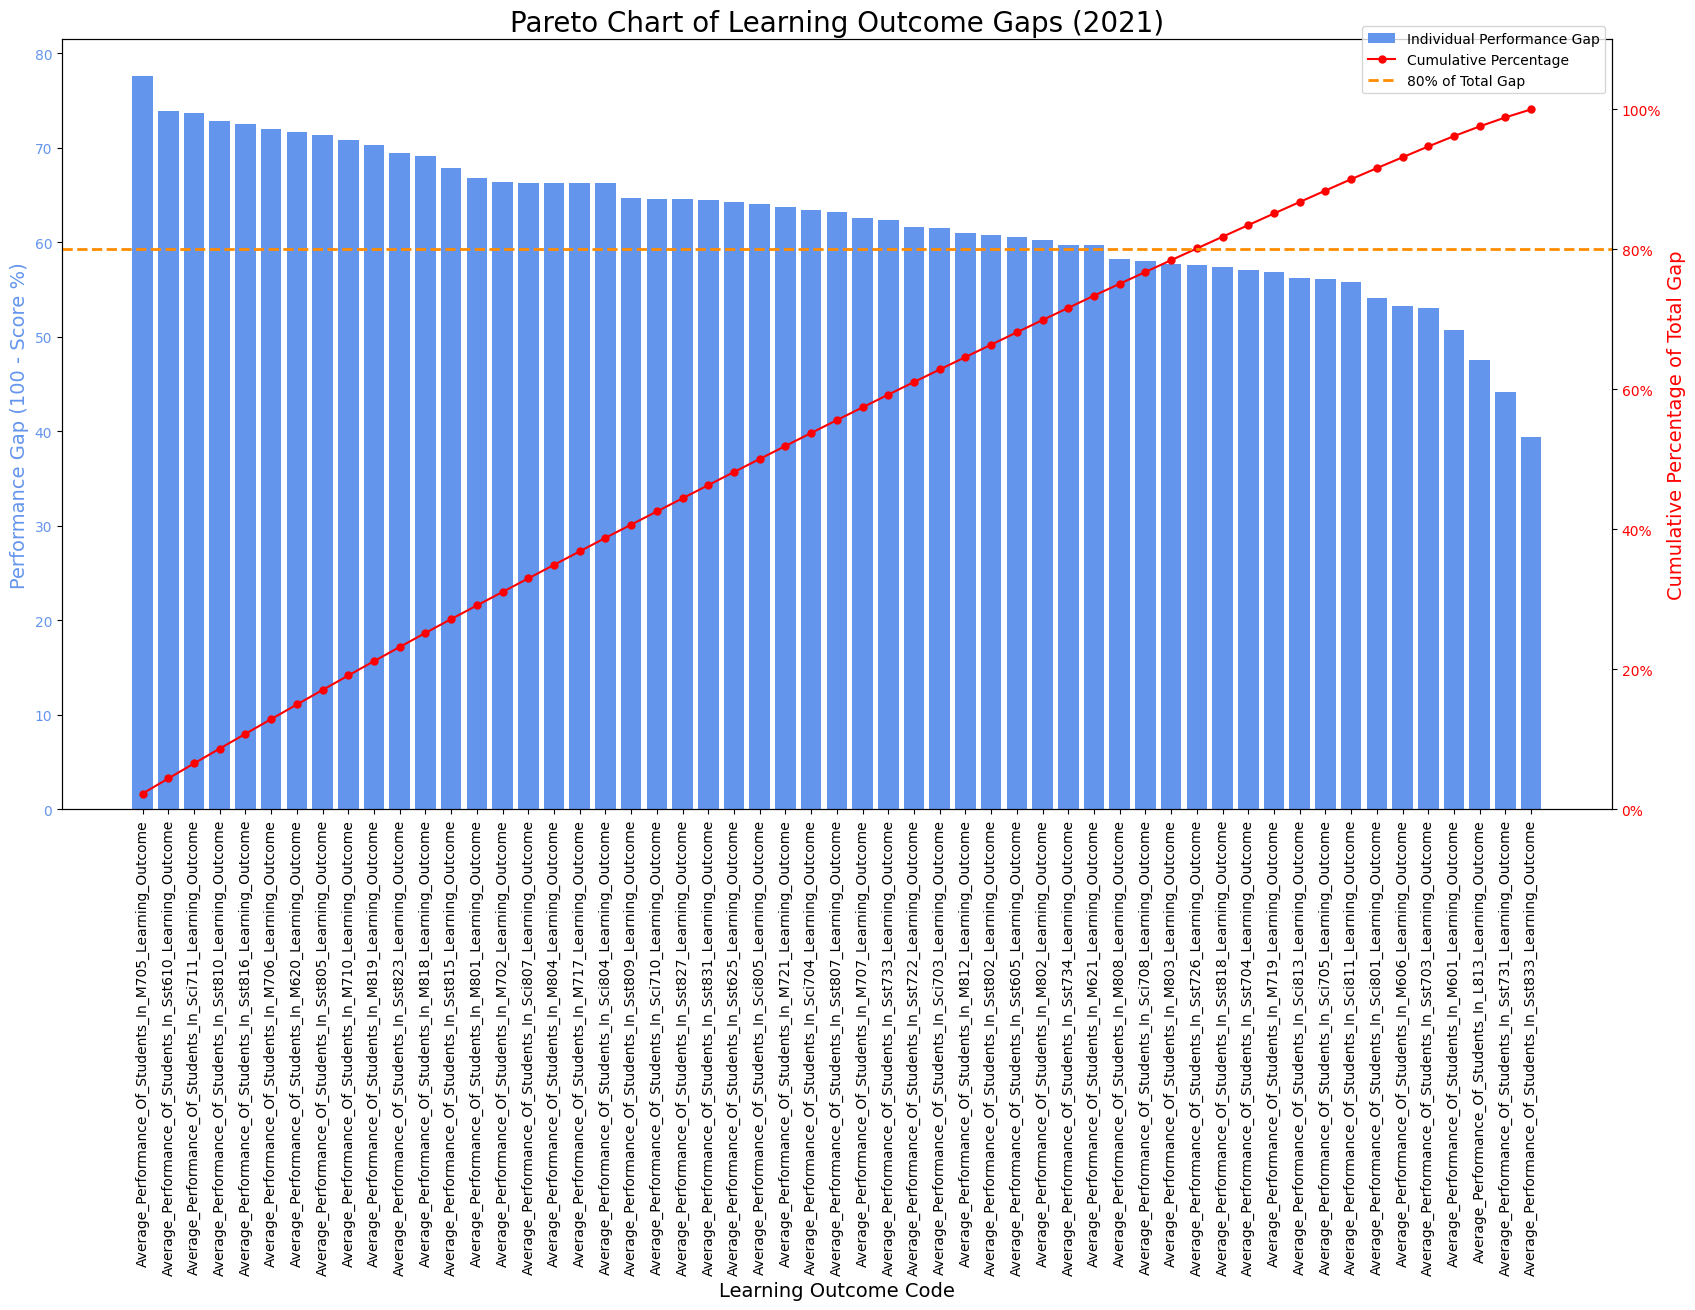

In [ ]:
# Import the Pareto function from matplotlib
from matplotlib.ticker import PercentFormatter

# --- 10.3: Create the plot ---
fig, ax = plt.subplots(figsize=(20, 10))

# Plot the bars (performance gap)
ax.bar(df_pareto.index, df_pareto['gap'], color='cornflowerblue', label='Individual Performance Gap')
ax.set_ylabel('Performance Gap (100 - Score %)', color='cornflowerblue', fontsize=14)
ax.tick_params(axis='y', labelcolor='cornflowerblue')
plt.xticks(rotation=90, fontsize=10)

# Create a second y-axis to plot the cumulative percentage line
ax2 = ax.twinx()
ax2.plot(df_pareto.index, df_pareto['cumulative_percentage'], color='red', marker='o', ms=5, label='Cumulative Percentage')
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel('Cumulative Percentage of Total Gap', color='red', fontsize=14)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110) # Set limit slightly above 100

# Add a line for the 80% mark
ax2.axhline(80, color='darkorange', linestyle='--', linewidth=2, label='80% of Total Gap')

# Final formatting
plt.title('Pareto Chart of Learning Outcome Gaps (2021)', fontsize=20)
ax.set_xlabel('Learning Outcome Code', fontsize=14)
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.show()

--- Expanded Correlation Heatmap ---


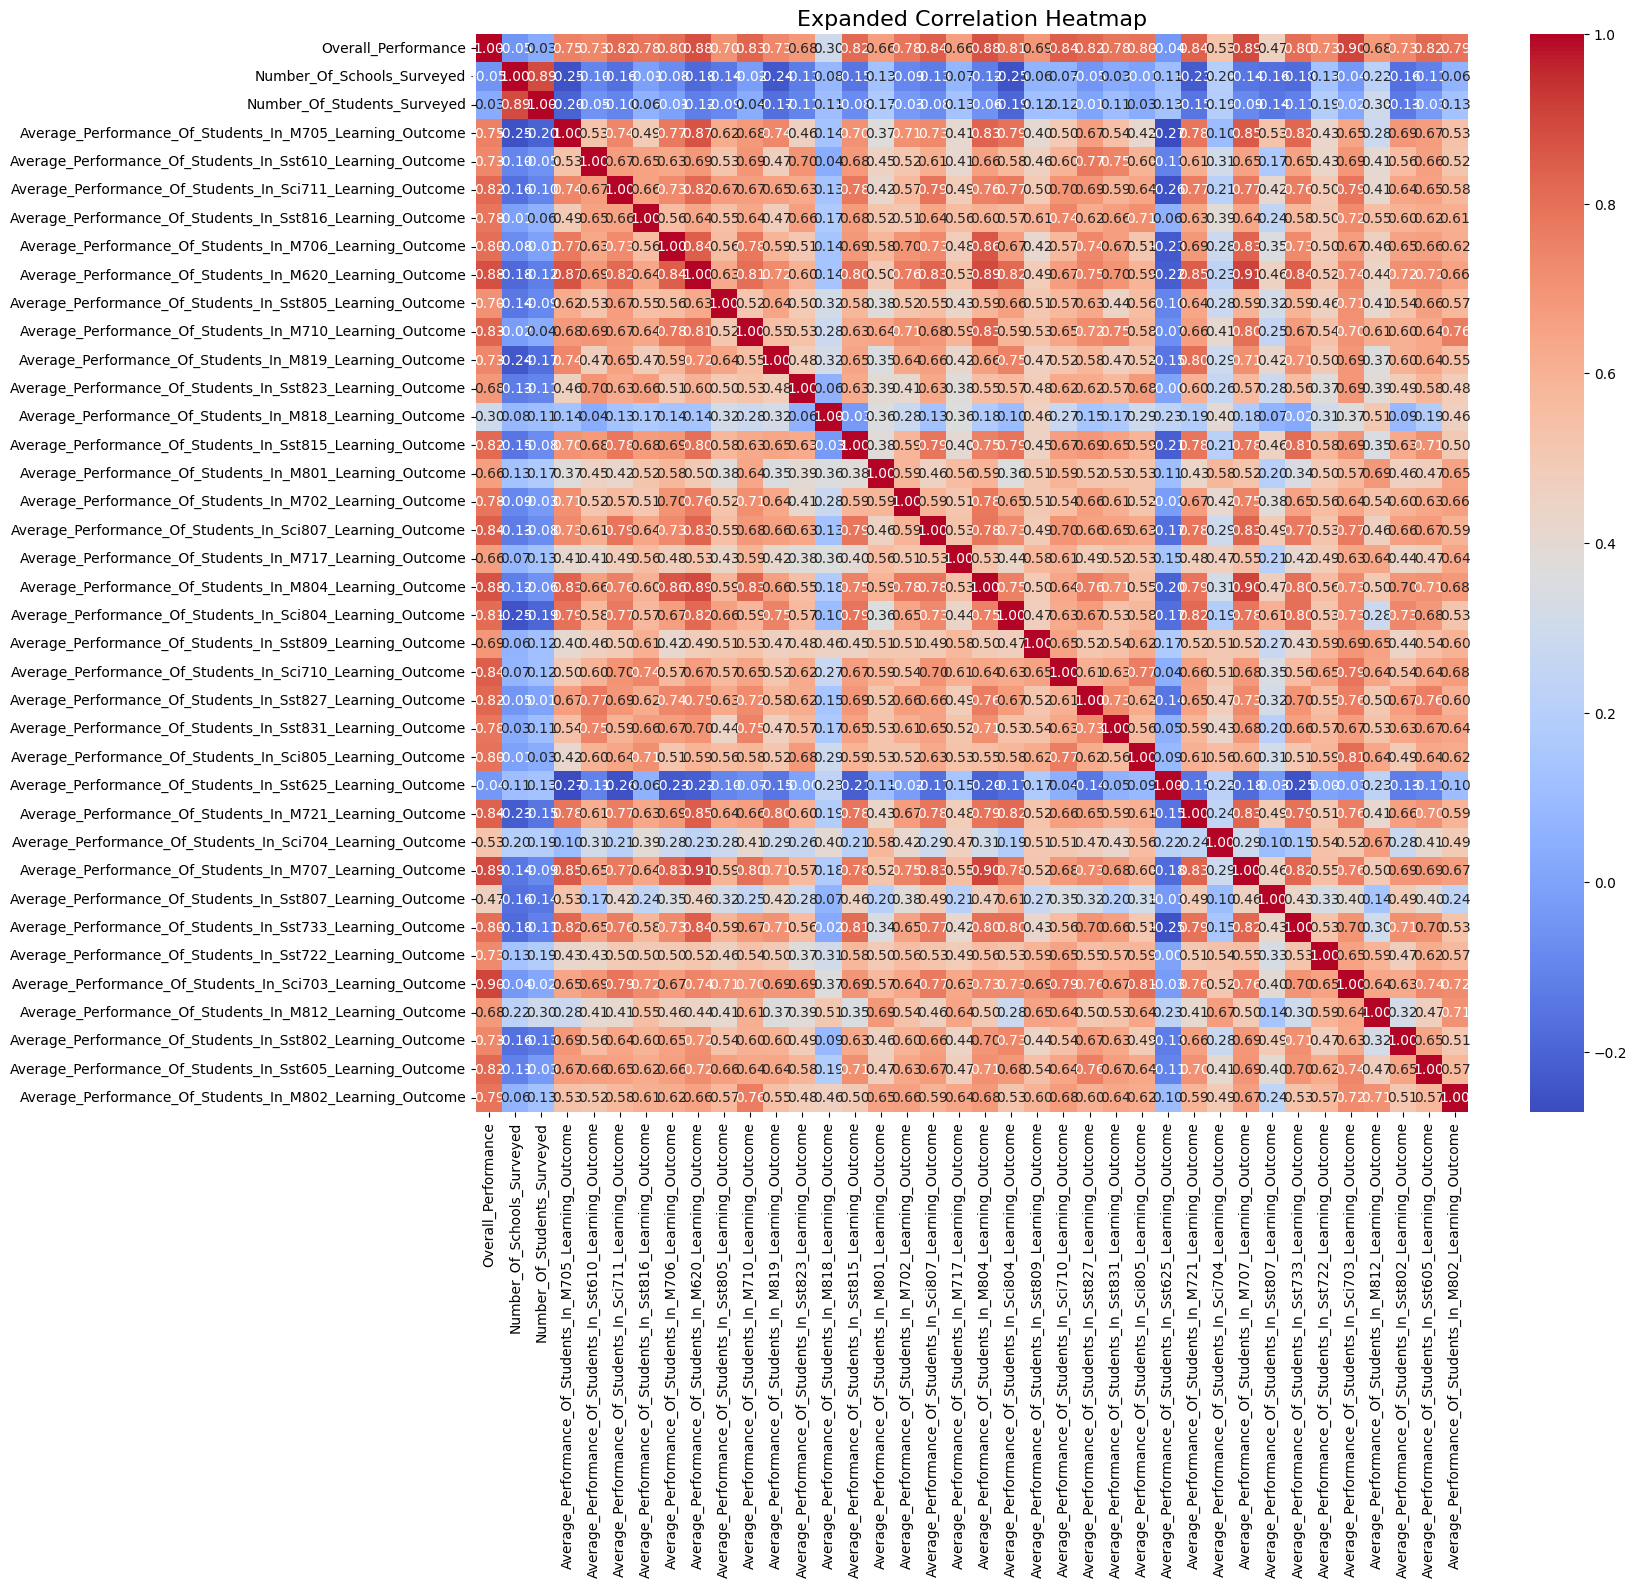



--- Additional Simple Linear Regressions ---

--- Simple Linear Regression: L813 vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.622
Model:                             OLS   Adj. R-squared:                  0.622
Method:                  Least Squares   F-statistic:                     2300.
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):          1.77e-297
Time:                         15:28:29   Log-Likelihood:                -4143.2
No. Observations:                 1399   AIC:                             8290.
Df Residuals:                     1397   BIC:                             8301.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                                               coef    std err          t

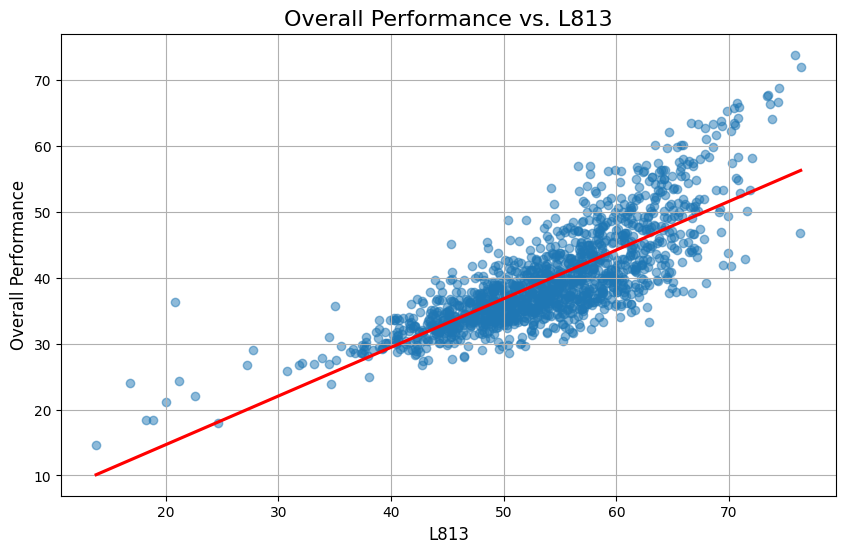

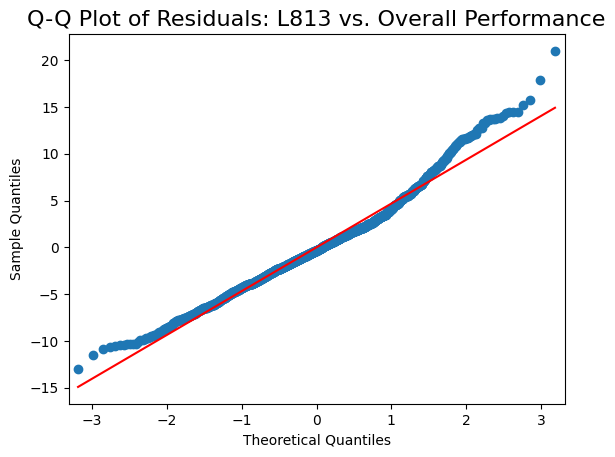


--- Simple Linear Regression: M801 vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.441
Model:                             OLS   Adj. R-squared:                  0.440
Method:                  Least Squares   F-statistic:                     1101.
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):          1.47e-178
Time:                         15:28:30   Log-Likelihood:                -4417.3
No. Observations:                 1399   AIC:                             8839.
Df Residuals:                     1397   BIC:                             8849.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------

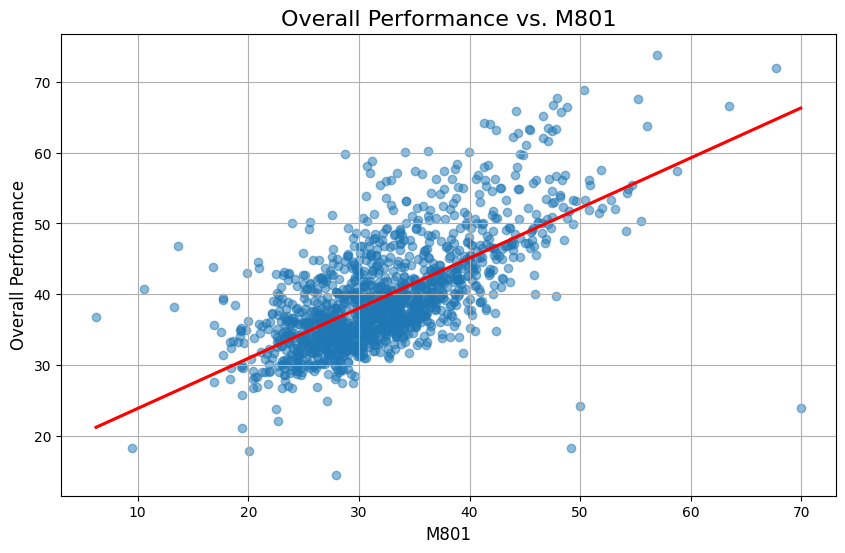

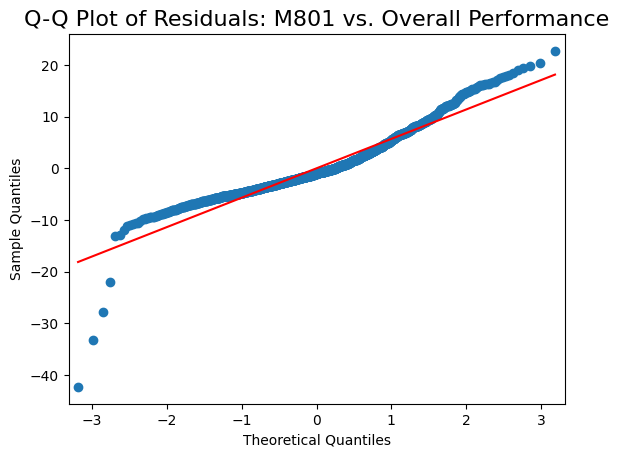


--- Simple Linear Regression: Sci801 vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.707
Model:                             OLS   Adj. R-squared:                  0.706
Method:                  Least Squares   F-statistic:                     3364.
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                         15:28:30   Log-Likelihood:                -3966.2
No. Observations:                 1399   AIC:                             7936.
Df Residuals:                     1397   BIC:                             7947.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------

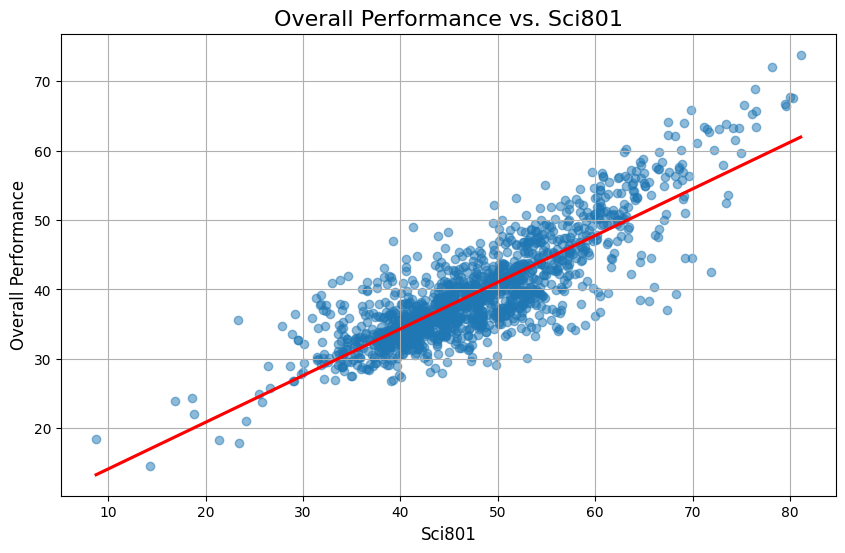

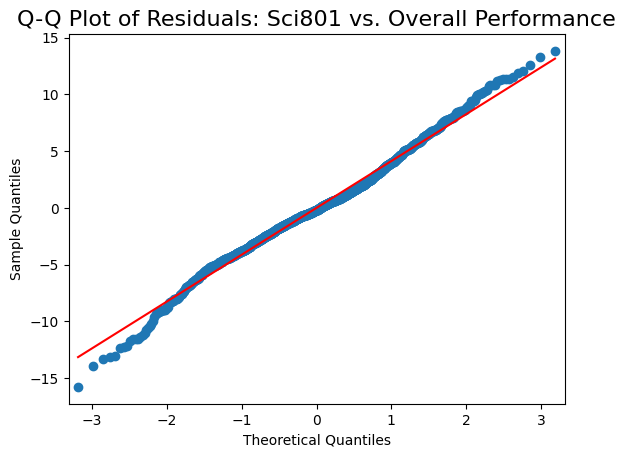


--- Simple Linear Regression: Sst802 vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.538
Model:                             OLS   Adj. R-squared:                  0.537
Method:                  Least Squares   F-statistic:                     1625.
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):          2.59e-236
Time:                         15:28:31   Log-Likelihood:                -4284.2
No. Observations:                 1399   AIC:                             8572.
Df Residuals:                     1397   BIC:                             8583.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------

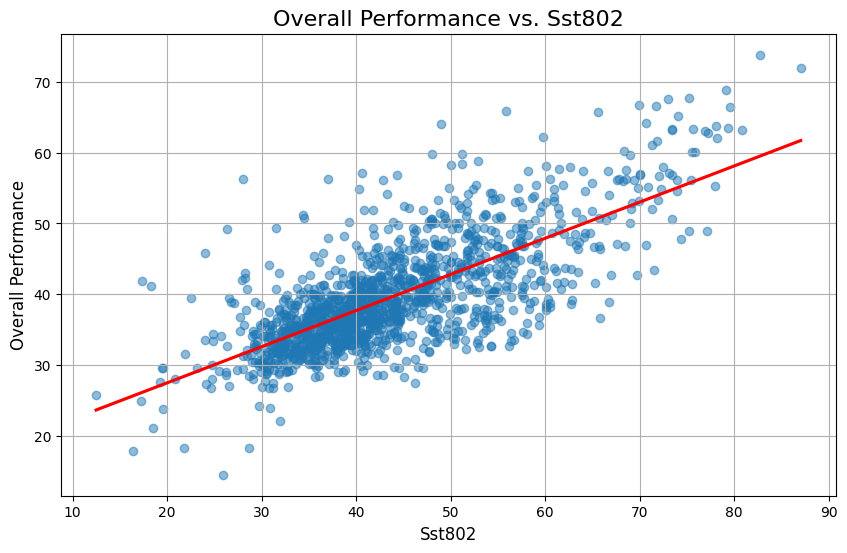

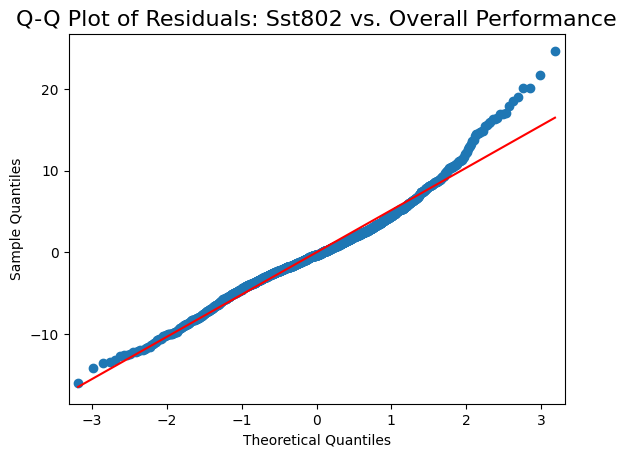


--- Simple Linear Regression: M606 vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.590
Model:                             OLS   Adj. R-squared:                  0.589
Method:                  Least Squares   F-statistic:                     2007.
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):          2.02e-272
Time:                         15:28:31   Log-Likelihood:                -4201.0
No. Observations:                 1399   AIC:                             8406.
Df Residuals:                     1397   BIC:                             8416.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------

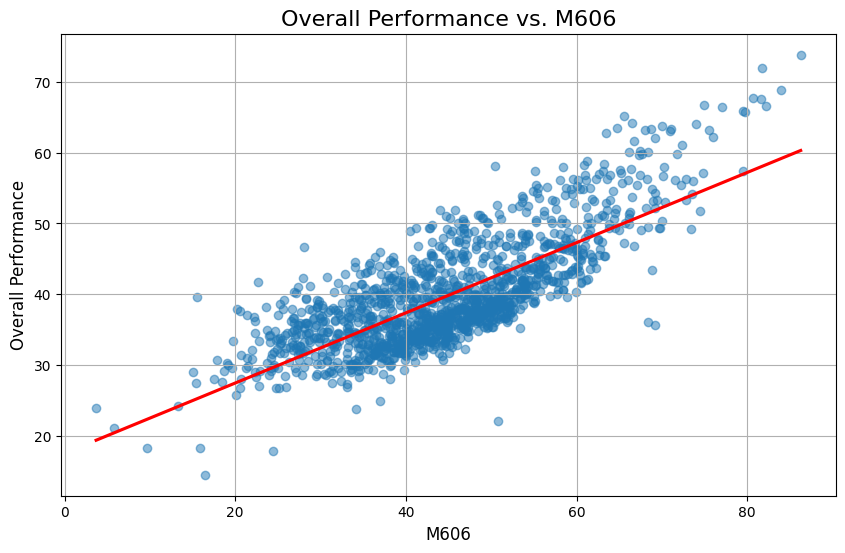

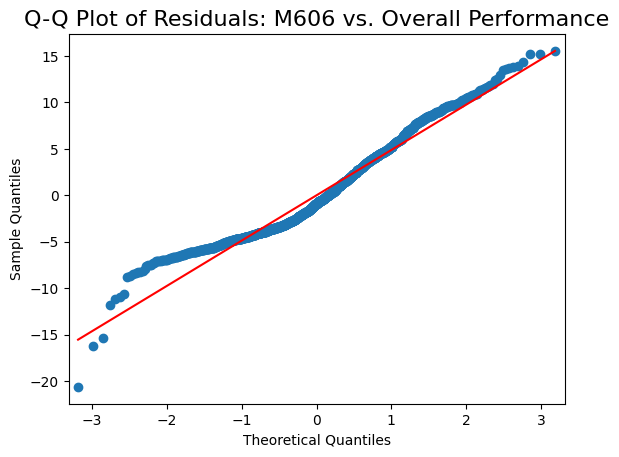


--- Simple Linear Regression: M702 vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.612
Model:                             OLS   Adj. R-squared:                  0.612
Method:                  Least Squares   F-statistic:                     2204.
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):          1.64e-289
Time:                         15:28:32   Log-Likelihood:                -4161.6
No. Observations:                 1399   AIC:                             8327.
Df Residuals:                     1397   BIC:                             8338.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------

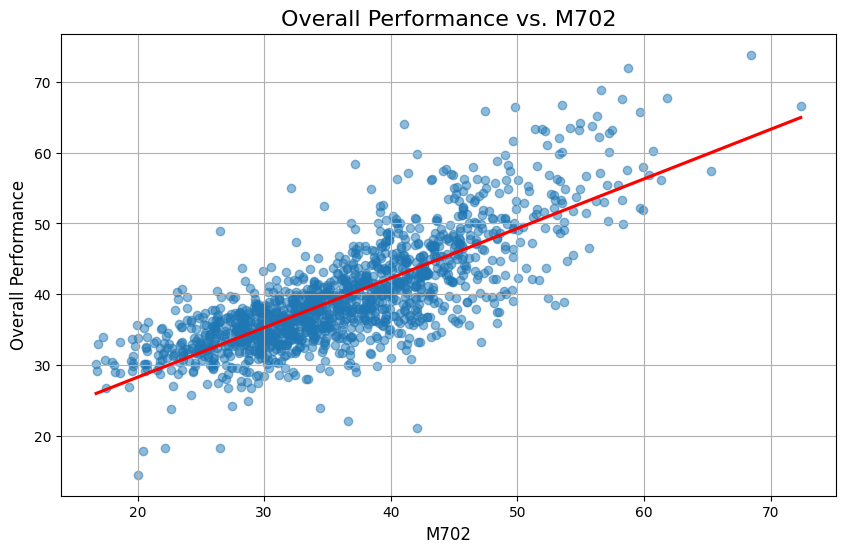

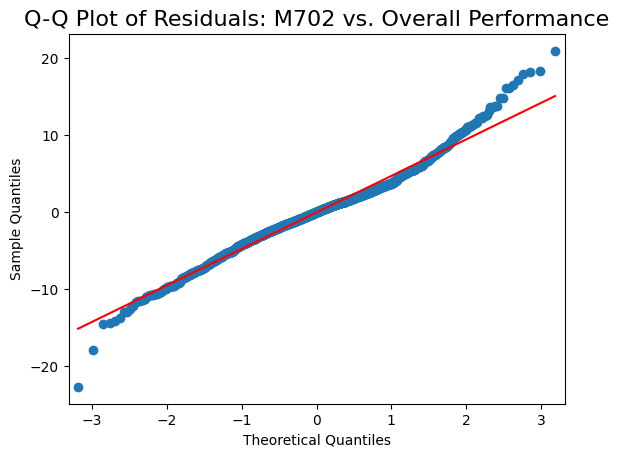


--- Simple Linear Regression: Sci703 vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.816
Model:                             OLS   Adj. R-squared:                  0.816
Method:                  Least Squares   F-statistic:                     6201.
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                         15:28:32   Log-Likelihood:                -3639.3
No. Observations:                 1399   AIC:                             7283.
Df Residuals:                     1397   BIC:                             7293.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------

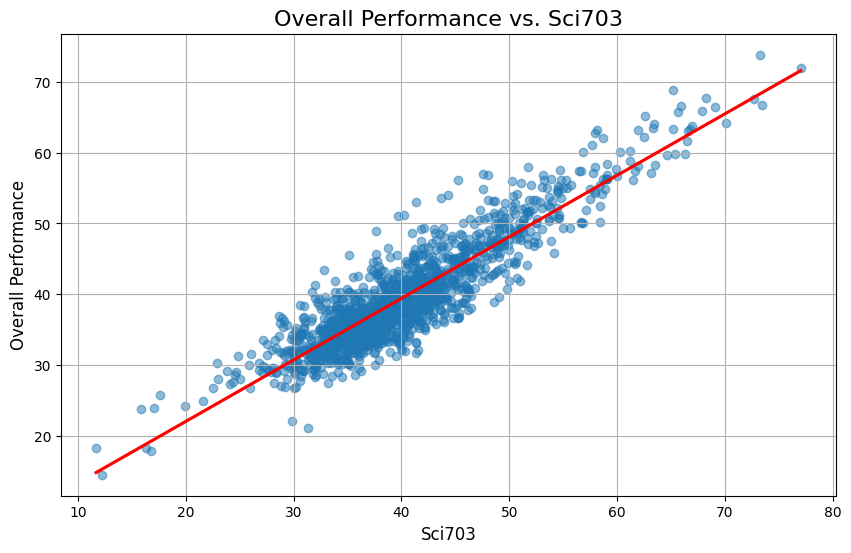

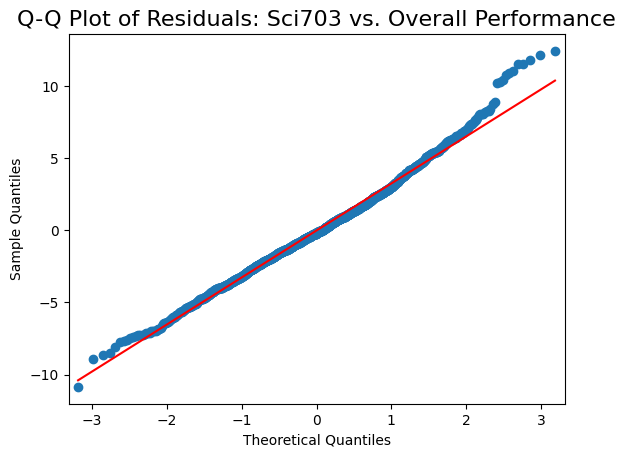


--- Simple Linear Regression: Sst605 vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.667
Model:                             OLS   Adj. R-squared:                  0.666
Method:                  Least Squares   F-statistic:                     2795.
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                         15:28:33   Log-Likelihood:                -4055.3
No. Observations:                 1399   AIC:                             8115.
Df Residuals:                     1397   BIC:                             8125.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------

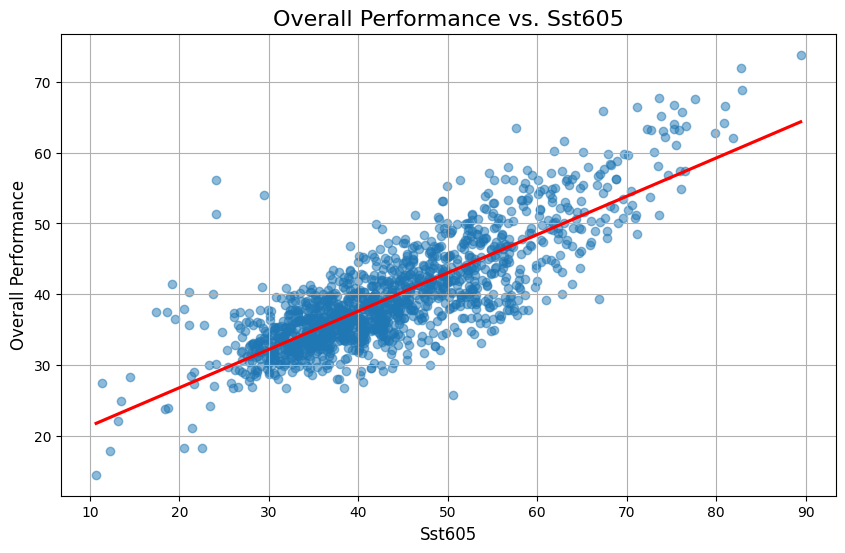

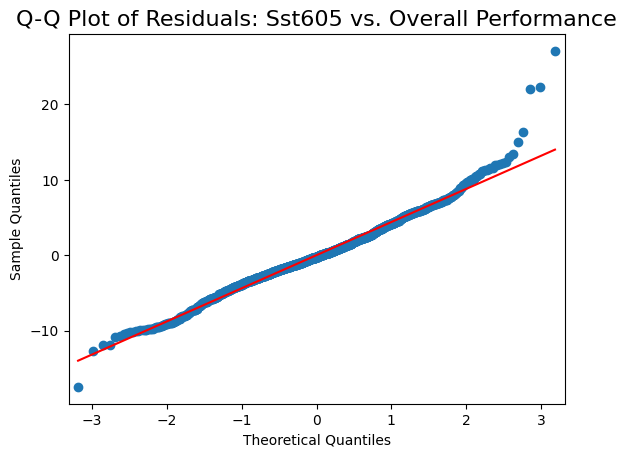


--- Simple Linear Regression: Sst722 vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.531
Model:                             OLS   Adj. R-squared:                  0.530
Method:                  Least Squares   F-statistic:                     1580.
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):          8.06e-232
Time:                         15:28:33   Log-Likelihood:                -4294.6
No. Observations:                 1399   AIC:                             8593.
Df Residuals:                     1397   BIC:                             8604.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------

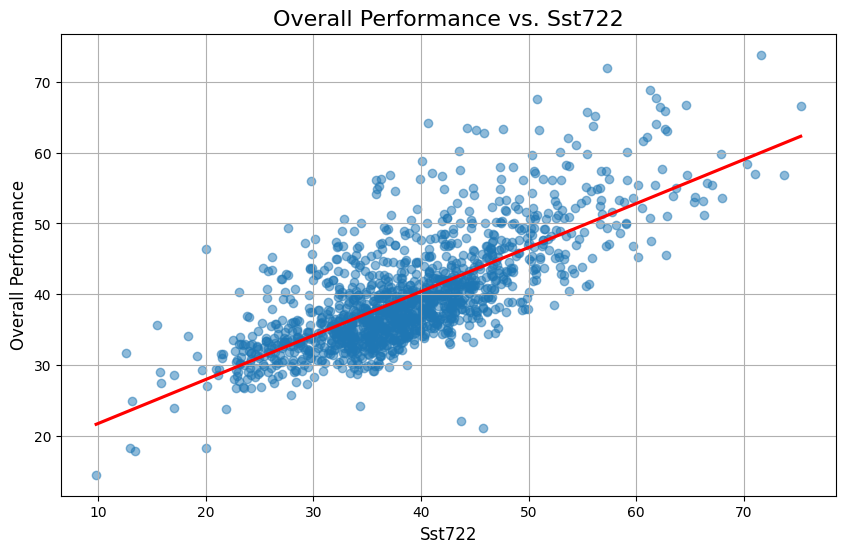

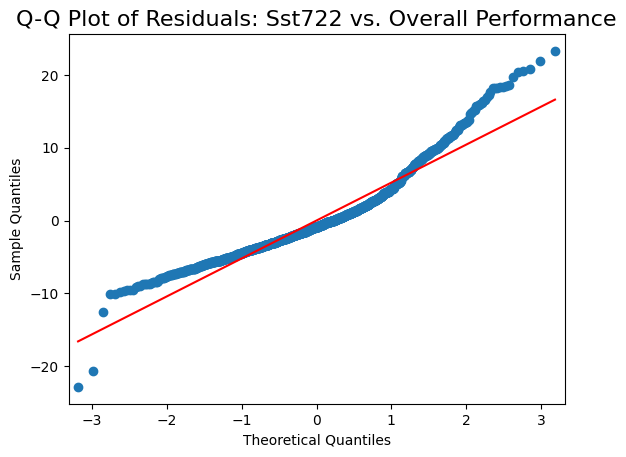


--- Simple Linear Regression: Number_Of_Schools_Surveyed vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.002
Model:                             OLS   Adj. R-squared:                  0.002
Method:                  Least Squares   F-statistic:                     3.141
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):             0.0766
Time:                         15:28:34   Log-Likelihood:                -4822.3
No. Observations:                 1399   AIC:                             9649.
Df Residuals:                     1397   BIC:                             9659.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------

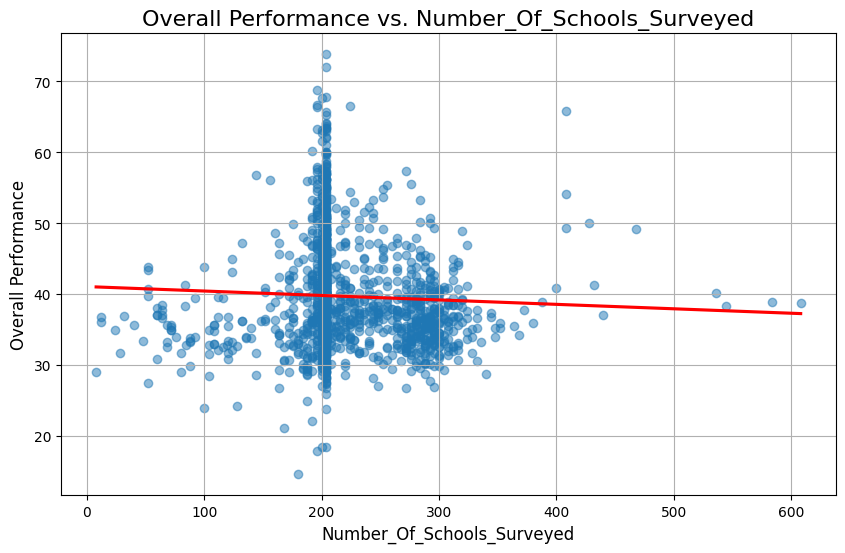

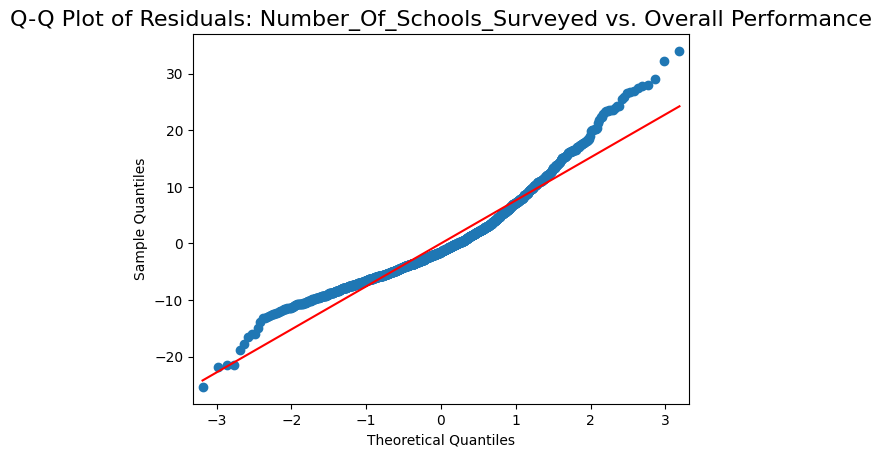


--- Simple Linear Regression: Number_Of_Students_Surveyed vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.001
Model:                             OLS   Adj. R-squared:                  0.000
Method:                  Least Squares   F-statistic:                     1.178
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):              0.278
Time:                         15:28:34   Log-Likelihood:                -4823.3
No. Observations:                 1399   AIC:                             9651.
Df Residuals:                     1397   BIC:                             9661.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------

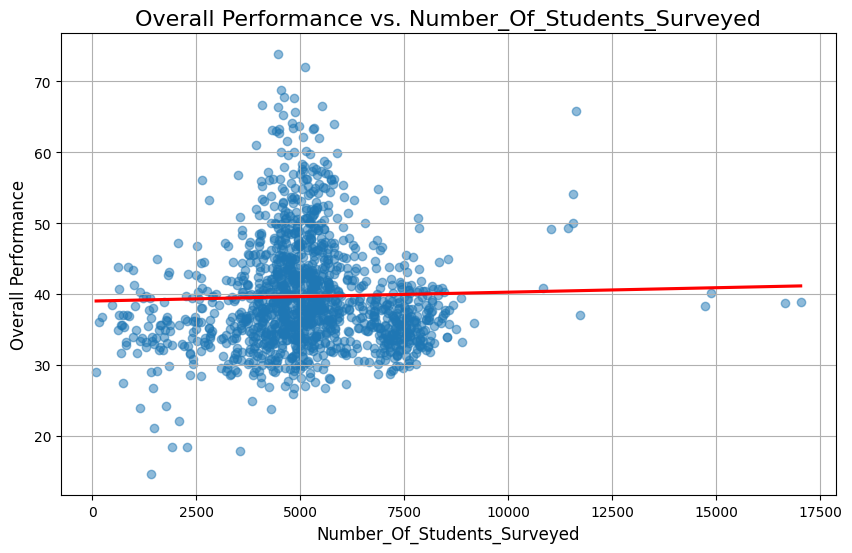

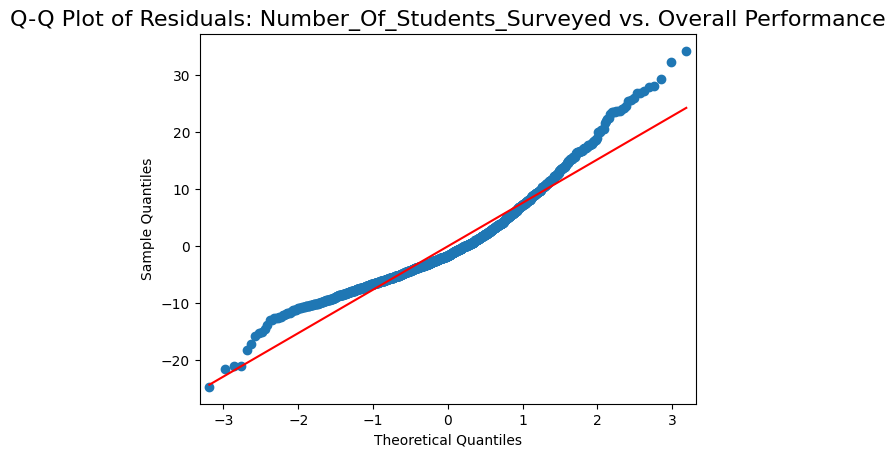


Analysis complete.


In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Data ---
file_path = 'cleaned_dataset_NAS.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: The file was not found at the path: {file_path}")
    exit()

# --- 2. Expanded Correlation Heatmap ---
print("--- Expanded Correlation Heatmap ---")

# Define the columns for the new heatmap, now with more variables
# Including all learning outcome columns
# learning_outcome_cols = [col for col in df.columns if col.startswith('Average_Performance')]
features_for_analysis = [
    'Overall_Performance',
    'Number_Of_Schools_Surveyed',
    'Number_Of_Students_Surveyed',
    'Average_Performance_Of_Students_In_M705_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst610_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci711_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst816_Learning_Outcome',
    'Average_Performance_Of_Students_In_M706_Learning_Outcome',
    'Average_Performance_Of_Students_In_M620_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst805_Learning_Outcome',
    'Average_Performance_Of_Students_In_M710_Learning_Outcome',
    'Average_Performance_Of_Students_In_M819_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst823_Learning_Outcome',
    'Average_Performance_Of_Students_In_M818_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst815_Learning_Outcome',
    'Average_Performance_Of_Students_In_M801_Learning_Outcome',
    'Average_Performance_Of_Students_In_M702_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci807_Learning_Outcome',
    'Average_Performance_Of_Students_In_M717_Learning_Outcome',
    'Average_Performance_Of_Students_In_M804_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci804_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst809_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci710_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst827_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst831_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci805_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst625_Learning_Outcome',
    'Average_Performance_Of_Students_In_M721_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci704_Learning_Outcome',
    'Average_Performance_Of_Students_In_M707_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst807_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst733_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst722_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci703_Learning_Outcome',
    'Average_Performance_Of_Students_In_M812_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst802_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst605_Learning_Outcome',
    'Average_Performance_Of_Students_In_M802_Learning_Outcome',

]

# Create and show the heatmap
df_corr_cleaned = df.dropna(subset=features_for_analysis)
plt.figure(figsize=(16, 14))
correlation_matrix_expanded = df_corr_cleaned[features_for_analysis].corr()
sns.heatmap(correlation_matrix_expanded, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Expanded Correlation Heatmap', fontsize=16)
plt.show()


# --- 3. More Simple Linear Regressions ---
print("\n\n--- Additional Simple Linear Regressions ---")

# The list now includes the original "new" variables plus the 5 additional ones
independent_vars_to_test = [
    'Average_Performance_Of_Students_In_L813_Learning_Outcome',
    'Average_Performance_Of_Students_In_M801_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci801_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst802_Learning_Outcome',
    'Average_Performance_Of_Students_In_M606_Learning_Outcome',
    'Average_Performance_Of_Students_In_M702_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci703_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst605_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst722_Learning_Outcome',
    'Number_Of_Schools_Surveyed',
    'Number_Of_Students_Surveyed'
]
y_simple = df['Overall_Performance']

for feature in independent_vars_to_test:
    # Shorten long column names for plot titles
    feature_title = feature.replace('Average_Performance_Of_Students_In_', '').replace('_Learning_Outcome', '')
    print(f"\n--- Simple Linear Regression: {feature_title} vs. Overall Performance ---")

    # Define independent variable and handle potential missing values
    X_simple = df[feature]
    df_temp = pd.concat([X_simple, y_simple], axis=1).dropna()
    X_simple_clean = df_temp[feature]
    y_simple_clean = df_temp['Overall_Performance']

    if len(X_simple_clean) < 2:
        print(f"Skipping {feature_title} due to insufficient data after handling NaNs.")
        continue

    # Add a constant (intercept) and fit the model
    X_simple_const = sm.add_constant(X_simple_clean)
    model_simple = sm.OLS(y_simple_clean, X_simple_const).fit()
    print(model_simple.summary())

    # Plot the simple regression and show it
    plt.figure(figsize=(10, 6))
    sns.regplot(x=X_simple_clean, y=y_simple_clean, ci=None, line_kws={'color':'red'}, scatter_kws={'alpha':0.5})
    plt.title(f'Overall Performance vs. {feature_title}', fontsize=16)
    plt.xlabel(feature_title, fontsize=12)
    plt.ylabel('Overall Performance', fontsize=12)
    plt.grid(True)
    plt.show()

    # Add Q-Q Plot
    fig = sm.qqplot(model_simple.resid, line='s')
    plt.title(f'Q-Q Plot of Residuals: {feature_title} vs. Overall Performance', fontsize=16)
    plt.show()


print("\nAnalysis complete.")



--- Multiple Linear Regression: Expanded Model with Other Attributes vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.974
Model:                             OLS   Adj. R-squared:                  0.974
Method:                  Least Squares   F-statistic:                     3254.
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                         15:28:35   Log-Likelihood:                -2267.1
No. Observations:                 1399   AIC:                             4568.
Df Residuals:                     1382   BIC:                             4657.
Df Model:                           16                                         
Covariance Type:             nonrobust                                         
                                                                 coef    std err          t      P>|t

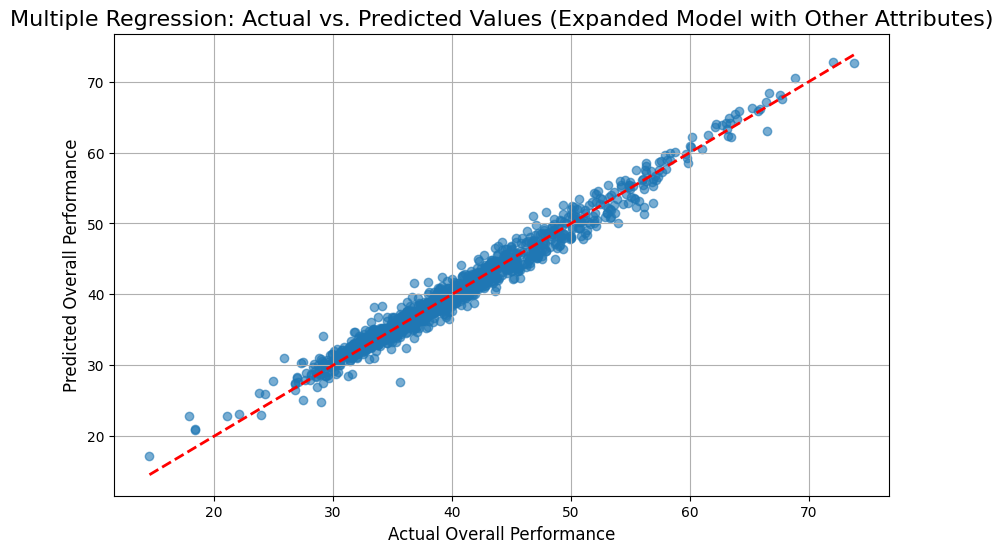

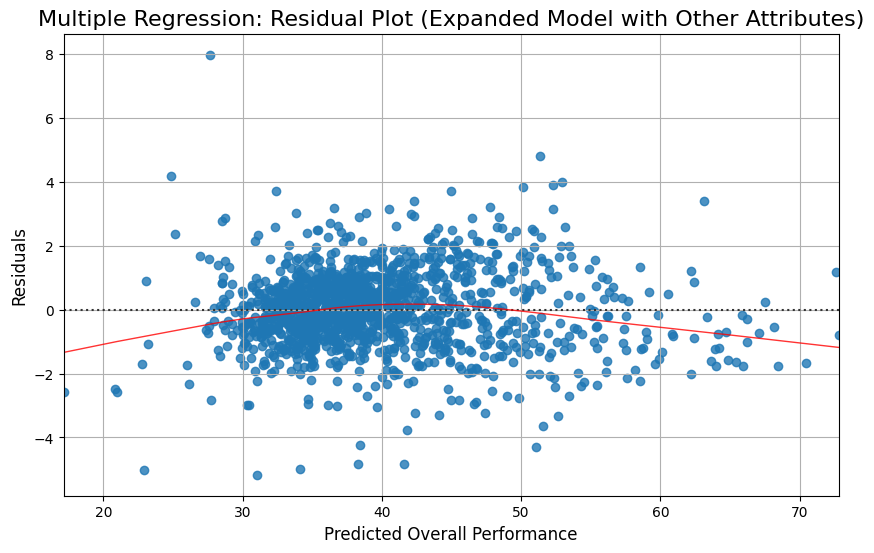

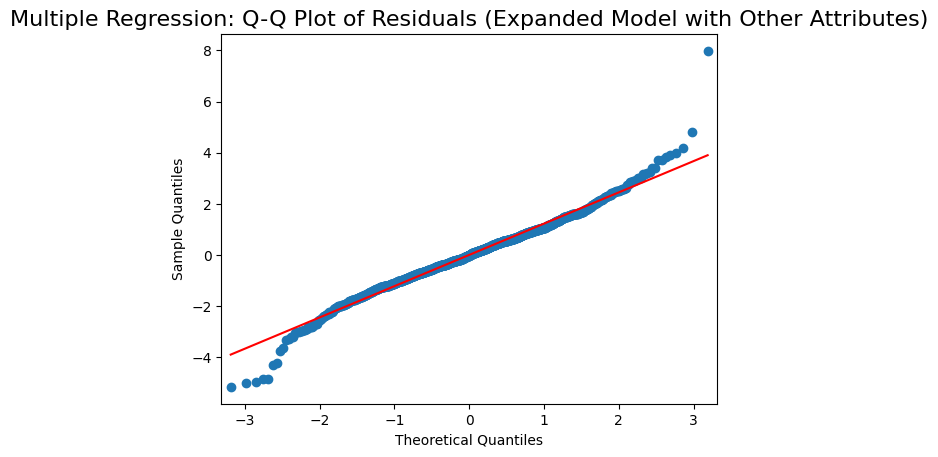

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Data ---
file_path = 'cleaned_dataset_NAS.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: The file was not found at the path: {file_path}")
    exit()

# --- 2. Multiple Linear Regression ---
print("\n\n--- Multiple Linear Regression: Expanded Model with Other Attributes vs. Overall Performance ---")

# Define dependent and independent variables
dependent_var = 'Overall_Performance'
independent_vars = [
    'Number_Of_Schools_Surveyed',
    'Number_Of_Students_Surveyed',
    'Average_Performance_Of_Students_In_M705_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci703_Learning_Outcome',
    'Average_Performance_Of_Students_In_M707_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci711_Learning_Outcome',
    'Average_Performance_Of_Students_In_M620_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst815_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci807_Learning_Outcome',
    'Average_Performance_Of_Students_In_M804_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci710_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst827_Learning_Outcome',
    'Average_Performance_Of_Students_In_M721_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst733_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst605_Learning_Outcome',
    'Average_Performance_Of_Students_In_M802_Learning_Outcome'
]

# Drop rows with missing values
df_cleaned = df.dropna(subset=[dependent_var] + independent_vars)

X_multi = df_cleaned[independent_vars]
y_multi = df_cleaned[dependent_var]

# Add a constant (intercept) and fit the model
X_multi_const = sm.add_constant(X_multi)
model_multi = sm.OLS(y_multi, X_multi_const).fit()

# Print the detailed summary
print(model_multi.summary())


# --- 3. Generate and Show Diagnostic Plots ---

# Plot 1: Actual vs. Predicted values
print("\n--- Displaying Diagnostic Plots ---")
predictions = model_multi.predict(X_multi_const)
plt.figure(figsize=(10, 6))
plt.scatter(y_multi, predictions, alpha=0.6)
plt.plot([y_multi.min(), y_multi.max()], [y_multi.min(), y_multi.max()], '--', color='red', linewidth=2)
plt.title('Multiple Regression: Actual vs. Predicted Values (Expanded Model with Other Attributes)', fontsize=16)
plt.xlabel('Actual Overall Performance', fontsize=12)
plt.ylabel('Predicted Overall Performance', fontsize=12)
plt.grid(True)
plt.show()

# Plot 2: Residual Plot
residuals = model_multi.resid
plt.figure(figsize=(10, 6))
sns.residplot(x=predictions, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Multiple Regression: Residual Plot (Expanded Model with Other Attributes)', fontsize=16)
plt.xlabel('Predicted Overall Performance', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True)
plt.show()

# Plot 3: Q-Q Plot of Residuals
fig = sm.qqplot(residuals, line='s')
plt.title('Multiple Regression: Q-Q Plot of Residuals (Expanded Model with Other Attributes)', fontsize=16)
plt.show()



--- Multiple Linear Regression: Expanded Model with Other Attributes, Year, and Class vs. Overall Performance ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.980
Model:                             OLS   Adj. R-squared:                  0.980
Method:                  Least Squares   F-statistic:                     4305.
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                         15:28:37   Log-Likelihood:                -2075.8
No. Observations:                 1399   AIC:                             4186.
Df Residuals:                     1382   BIC:                             4275.
Df Model:                           16                                         
Covariance Type:             nonrobust                                         
                                                                 coef    std err    

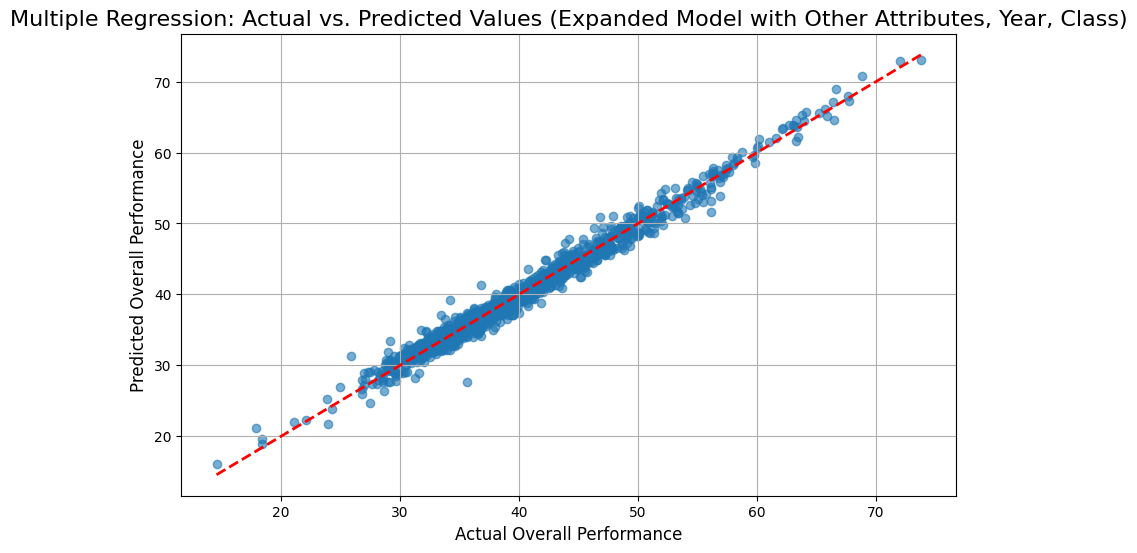

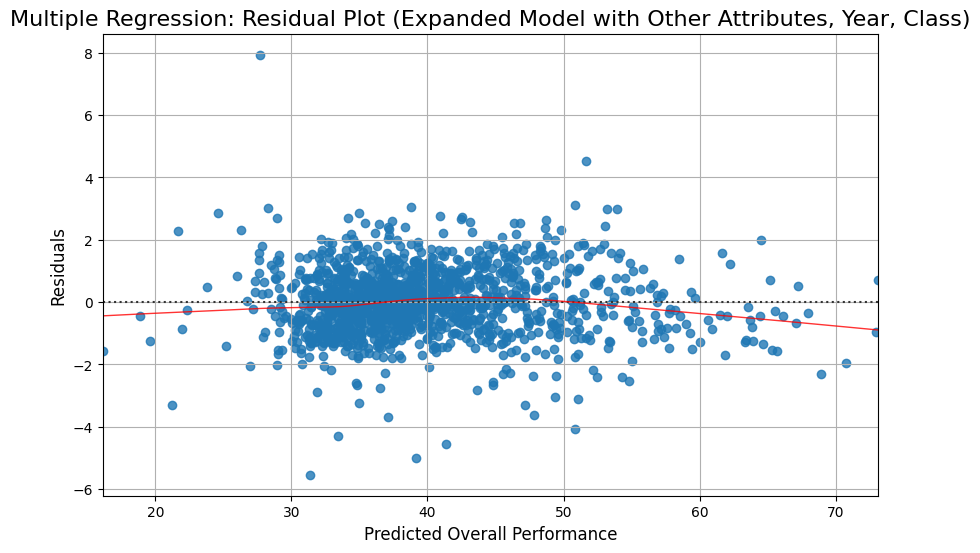

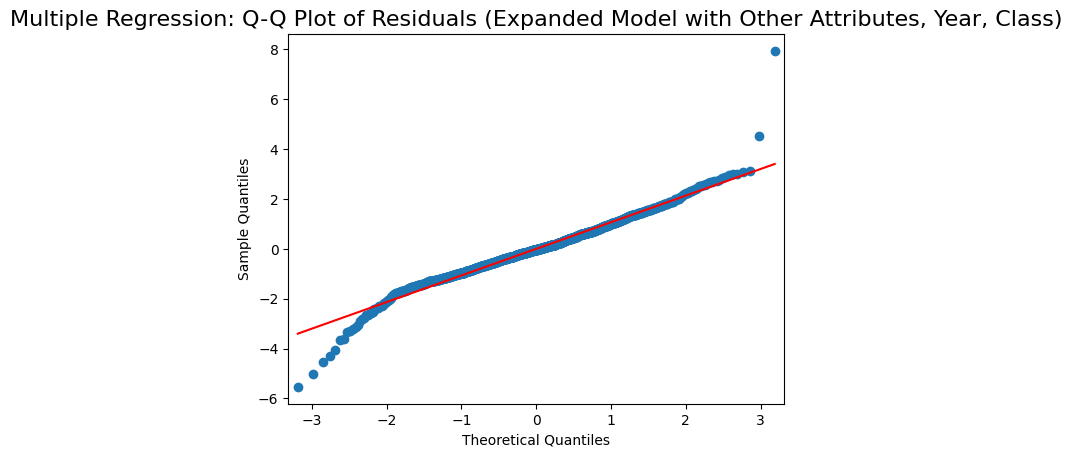

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Data ---
file_path = 'cleaned_dataset_NAS.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: The file was not found at the path: {file_path}")
    exit()

# --- 2. Multiple Linear Regression ---
print("\n\n--- Multiple Linear Regression: Expanded Model with Other Attributes, Year, and Class vs. Overall Performance ---")

# Define dependent and independent variables
dependent_var = 'Overall_Performance'
independent_vars = [
    'Number_Of_Schools_Surveyed',
    'Number_Of_Students_Surveyed',
    'Average_Performance_Of_Students_In_Sci703_Learning_Outcome',
    'Average_Performance_Of_Students_In_M707_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci711_Learning_Outcome',
    'Average_Performance_Of_Students_In_M620_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst815_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci807_Learning_Outcome',
    'Average_Performance_Of_Students_In_M804_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci710_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst827_Learning_Outcome',
    'Average_Performance_Of_Students_In_M721_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst733_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst605_Learning_Outcome',
    'Average_Performance_Of_Students_In_M802_Learning_Outcome',
    'Year', # Added Year
    'Class' # Added Class
]

# Drop rows with missing values
df_cleaned = df.dropna(subset=[dependent_var] + independent_vars)

X_multi = df_cleaned[independent_vars]
y_multi = df_cleaned[dependent_var]

# Add a constant (intercept) and fit the model
X_multi_const = sm.add_constant(X_multi)
model_multi = sm.OLS(y_multi, X_multi_const).fit()

# Print the detailed summary
print(model_multi.summary())


# --- 3. Generate and Show Diagnostic Plots ---

# Plot 1: Actual vs. Predicted values
print("\n--- Displaying Diagnostic Plots ---")
predictions = model_multi.predict(X_multi_const)
plt.figure(figsize=(10, 6))
plt.scatter(y_multi, predictions, alpha=0.6)
plt.plot([y_multi.min(), y_multi.max()], [y_multi.min(), y_multi.max()], '--', color='red', linewidth=2)
plt.title('Multiple Regression: Actual vs. Predicted Values (Expanded Model with Other Attributes, Year, Class)', fontsize=16)
plt.xlabel('Actual Overall Performance', fontsize=12)
plt.ylabel('Predicted Overall Performance', fontsize=12)
plt.grid(True)
plt.show()

# Plot 2: Residual Plot
residuals = model_multi.resid
plt.figure(figsize=(10, 6))
sns.residplot(x=predictions, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Multiple Regression: Residual Plot (Expanded Model with Other Attributes, Year, Class)', fontsize=16)
plt.xlabel('Predicted Overall Performance', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True)
plt.show()

# Plot 3: Q-Q Plot of Residuals
fig = sm.qqplot(residuals, line='s')
plt.title('Multiple Regression: Q-Q Plot of Residuals (Expanded Model with Other Attributes, Year, Class)', fontsize=16)
plt.show()

--- State-Level Aggregated Data for Clustering ---
                         State  Math_Performance  Science_Performance  \
0  Andaman and Nicobar Islands         33.037667            35.781389   
1               Andhra Pradesh         34.696300            34.713833   
2            Arunachal Pradesh         31.954430            37.825717   
3                        Assam         35.995182            37.184192   
4                        Bihar         38.189592            37.447500   

   SST_Performance  Language_Performance  
0        33.662727             48.220000  
1        34.178409             49.332000  
2        36.132518             53.275400  
3        38.317934             48.210303  
4        38.520323             48.230263  


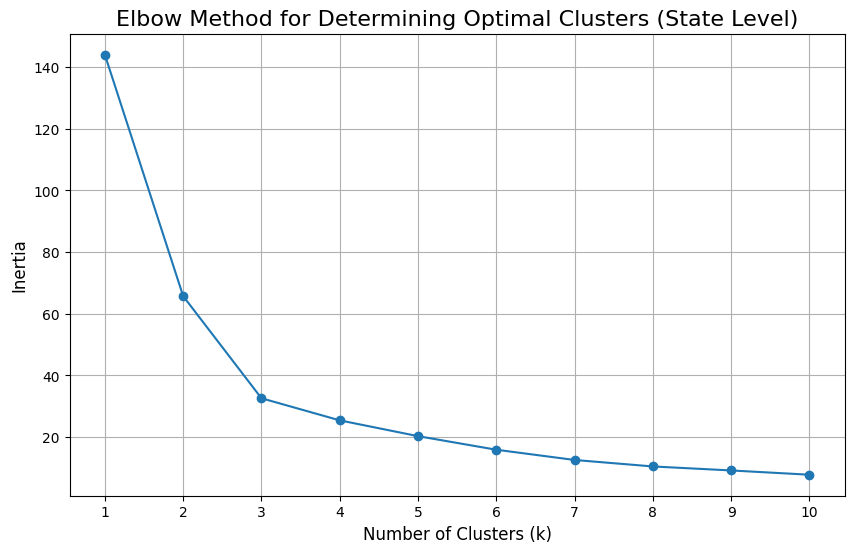


--- Elbow Method Plot for State-Level Data Generated ---
Examine the plot above to choose an appropriate number of clusters (k) for states.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- 1. Aggregate Data to State Level ---
# Using the same features used for district clustering
features_for_clustering = ['Math_Performance', 'Science_Performance', 'SST_Performance', 'Language_Performance']

df_clustering = df_2021 # Define df_clustering from df_2021

# Calculate the mean of the clustering features for each state
df_state_clustering = df_clustering.groupby('State')[features_for_clustering].mean().reset_index()

print("--- State-Level Aggregated Data for Clustering ---")
print(df_state_clustering.head())

# --- 2. Prepare Data for State-Level Clustering ---
# Standardize the aggregated features
X_state_clustering = df_state_clustering[features_for_clustering]
scaler_state = StandardScaler()
X_state_scaled = scaler_state.fit_transform(X_state_clustering)

# --- 3. Determine Optimal Number of Clusters for States (Elbow Method) ---
inertia_state = []
k_range_state = range(1, 11) # Test a range of cluster numbers

for k in k_range_state:
    kmeans_state = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_state.fit(X_state_scaled)
    inertia_state.append(kmeans_state.inertia_)

# Plot the Elbow Method graph for state-level data
plt.figure(figsize=(10, 6))
plt.plot(k_range_state, inertia_state, marker='o')
plt.title('Elbow Method for Determining Optimal Clusters (State Level)', fontsize=16)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.xticks(k_range_state)
plt.grid(True)
plt.show()

print("\n--- Elbow Method Plot for State-Level Data Generated ---")
print("Examine the plot above to choose an appropriate number of clusters (k) for states.")


--- State-Level K-Means Clustering Performed with k=3 ---

--- State Cluster Summary (Average Subject Performance) ---
   Math_Performance  Science_Performance  SST_Performance  \
0         31.201366            33.996766        33.451714   
1         46.359981            46.813485        46.208855   
2         34.754168            38.882321        37.831056   

   Language_Performance  Count_of_States  
0             46.120428                8  
1             63.240985                4  
2             54.382168               24  

--- States in Each Cluster ---
Cluster 0: ['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Chhattisgarh', 'Meghalaya', 'Mizoram', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh']
Cluster 1: ['Chandigarh', 'Haryana', 'Punjab', 'Rajasthan']
Cluster 2: ['Arunachal Pradesh', 'Assam', 'Bihar', 'Delhi', 'Goa', 'Gujarat', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'N

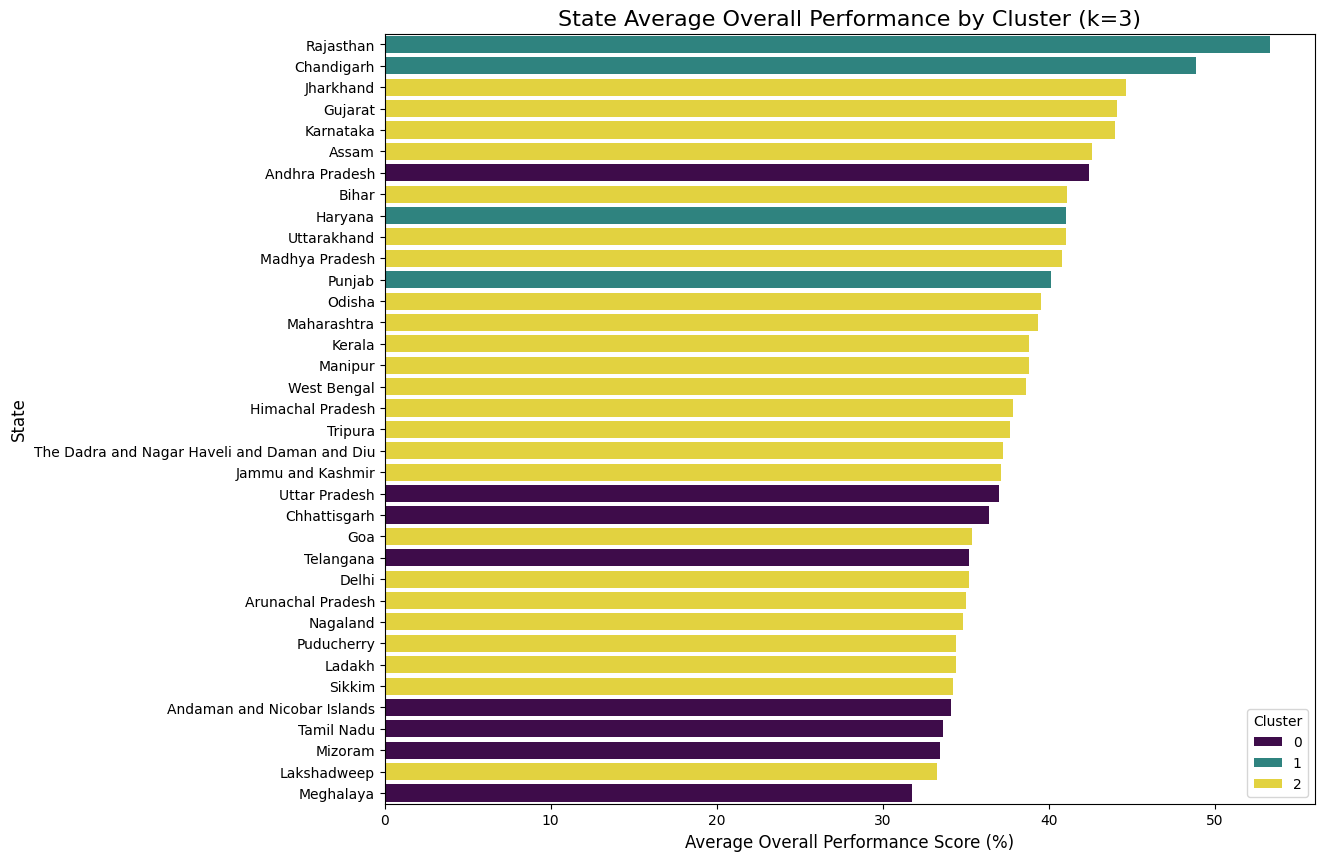


Insights gathered from state-level clustering.


In [ ]:
# --- 4. Perform State-Level K-Means Clustering with k=3 ---
# We will use the scaled state data from the previous step (X_state_scaled)
n_clusters_state = 3
kmeans_state = KMeans(n_clusters=n_clusters_state, random_state=42, n_init=10)
df_state_clustering['State_Cluster'] = kmeans_state.fit_predict(X_state_scaled)

print(f"\n--- State-Level K-Means Clustering Performed with k={n_clusters_state} ---")

# --- 5. Analyze State Cluster Characteristics ---
# Group by state cluster and calculate the mean of the original features for each cluster
state_cluster_centers_original_scale = scaler_state.inverse_transform(kmeans_state.cluster_centers_)
state_cluster_summary = pd.DataFrame(state_cluster_centers_original_scale, columns=features_for_clustering)
state_cluster_summary['Count_of_States'] = df_state_clustering['State_Cluster'].value_counts().sort_index()

print("\n--- State Cluster Summary (Average Subject Performance) ---")
print(state_cluster_summary)

# Let's also see which states fall into each cluster
print("\n--- States in Each Cluster ---")
for cluster_id in sorted(df_state_clustering['State_Cluster'].unique()):
    states_in_cluster = df_state_clustering[df_state_clustering['State_Cluster'] == cluster_id]['State'].tolist()
    print(f"Cluster {cluster_id}: {states_in_cluster}")

# --- 6. Visualize State Clusters (Example: Bar plot of overall performance by state, colored by cluster) ---
# Merge with overall performance if not already in df_state_clustering
# Assuming df_state_clustering already has 'Overall_Performance' from previous steps, if not merge it
if 'Overall_Performance' not in df_state_clustering.columns:
    df_state_overall = df.groupby('State')['Overall_Performance'].mean().reset_index()
    df_state_clustering = pd.merge(df_state_clustering, df_state_overall, on='State')


plt.figure(figsize=(12, 10))
sns.barplot(x='Overall_Performance', y='State', hue='State_Cluster', data=df_state_clustering.sort_values('Overall_Performance', ascending=False), palette='viridis', dodge=False)
plt.title(f'State Average Overall Performance by Cluster (k={n_clusters_state})', fontsize=16)
plt.xlabel('Average Overall Performance Score (%)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.legend(title='Cluster')
plt.show()

print("\nInsights gathered from state-level clustering.")


--- Comparing Performance in Hardest Learning Outcomes across State Clusters ---
Merged 'State_Cluster' into df_clustering.

Average Performance in Hardest Learning Outcomes by State Cluster:
               Average_Performance_Of_Students_In_M705_Learning_Outcome  \
State_Cluster                                                             
0                                                      19.305000          
1                                                      32.166282          
2                                                      21.968409          

               Average_Performance_Of_Students_In_Sst610_Learning_Outcome  \
State_Cluster                                                               
0                                                      24.160585            
1                                                      32.961026            
2                                                      25.739114            

               Average_Performance_Of_Student

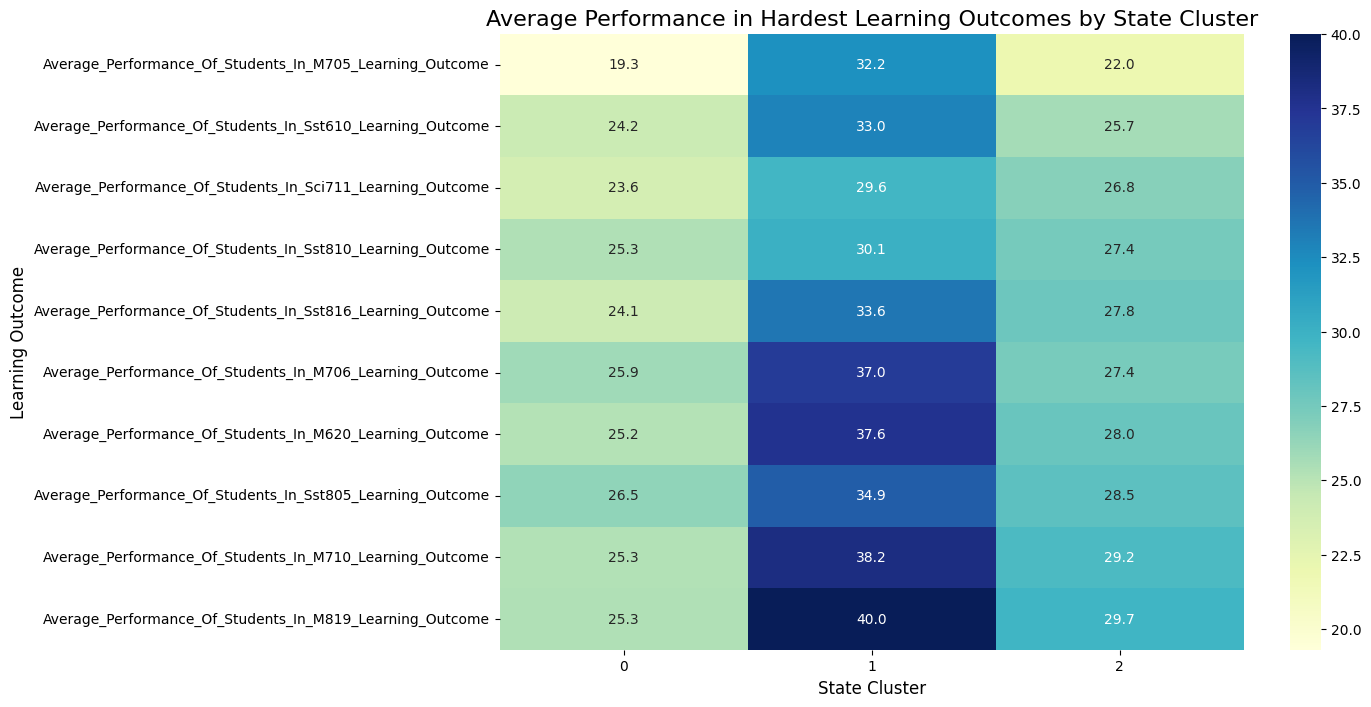


Analysis of state clusters with additional attributes complete.


In [ ]:
# --- Compare Specific Learning Outcome Performance across State Clusters ---
print("\n--- Comparing Performance in Hardest Learning Outcomes across State Clusters ---")

# Assuming hardest_topics contains the list of column names for the hardest topics
if 'hardest_topics' in locals() and not hardest_topics.empty:
    # Get the original column names from the hardest_topics index
    hardest_topic_cols = [f'Average_Performance_Of_Students_In_{topic}_Learning_Outcome' for topic in hardest_topics.index.str.replace('_Learning_Outcome', '').str.replace('Average_Performance_Of_Students_In_', '')]
    # Ensure these columns exist in the district dataframe
    hardest_topic_cols = [col for col in hardest_topic_cols if col in df_clustering.columns]

    if hardest_topic_cols:
        # Merge State_Cluster information into df_clustering (df_2021) if not already there
        if 'State_Cluster' not in df_clustering.columns:
            df_clustering = pd.merge(df_clustering, df_state_clustering[['State', 'State_Cluster']], on='State', how='left')
            print("Merged 'State_Cluster' into df_clustering.")

        # Calculate average performance for hardest topics by State Cluster
        state_cluster_hardest_topics_avg = df_clustering.groupby('State_Cluster')[hardest_topic_cols].mean()

        print("\nAverage Performance in Hardest Learning Outcomes by State Cluster:")
        print(state_cluster_hardest_topics_avg)

        # Visualize as a heatmap or bar plot
        plt.figure(figsize=(12, 8))
        sns.heatmap(state_cluster_hardest_topics_avg.T, annot=True, cmap='YlGnBu', fmt=".1f")
        plt.title('Average Performance in Hardest Learning Outcomes by State Cluster', fontsize=16)
        plt.xlabel('State Cluster', fontsize=12)
        plt.ylabel('Learning Outcome', fontsize=12)
        plt.yticks(rotation=0)
        plt.show()

    else:
        print("\nCould not find corresponding columns for hardest topics in the DataFrame.")
else:
    print("\n'hardest_topics' variable not found or empty. Please run the Pareto analysis step first.")

print("\nAnalysis of state clusters with additional attributes complete.")

--- Visualizing District Cluster Separation ---

District clustering results or clustering features not found in the DataFrame.

--- Visualizing State Cluster Separation ---


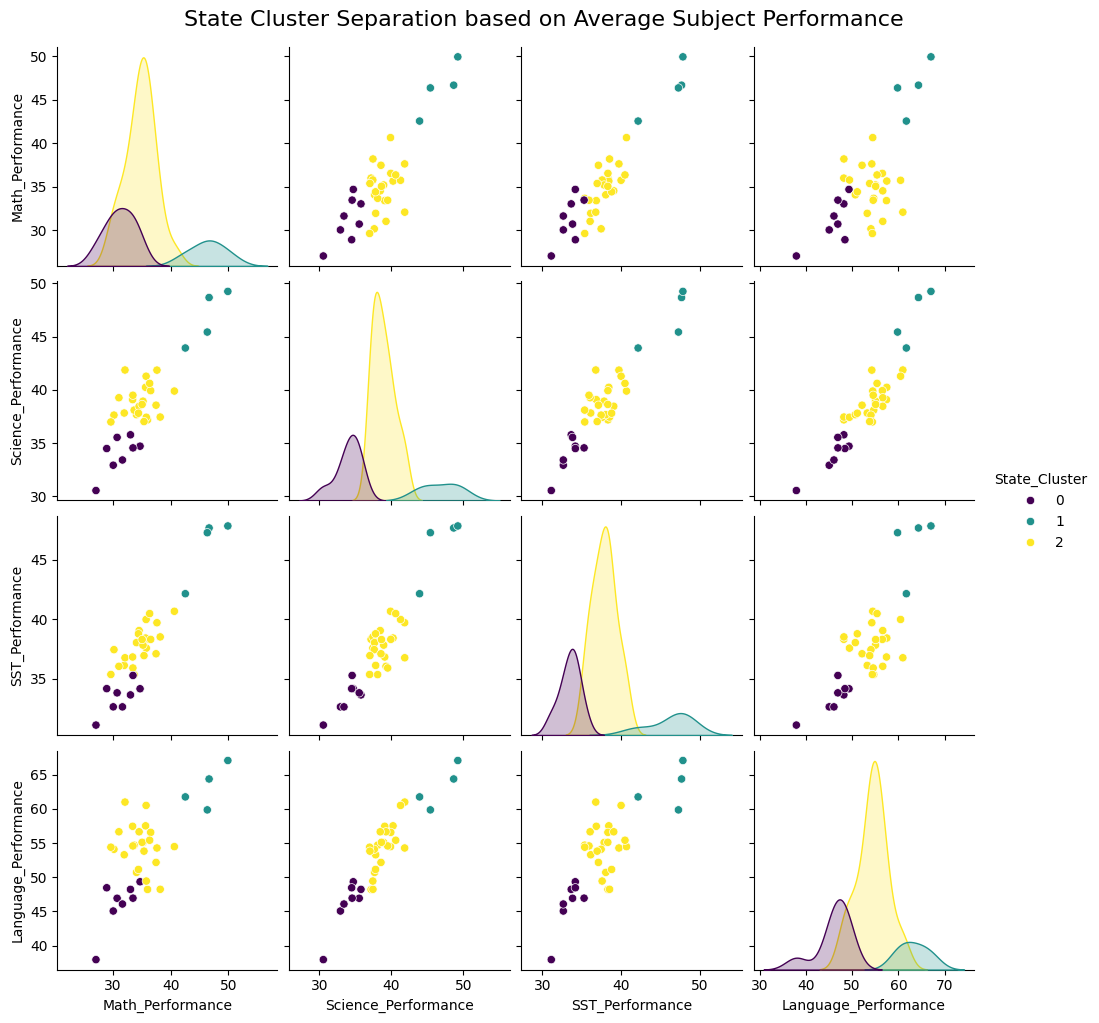


Cluster separation visualizations generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Visualize District Cluster Separation ---
print("--- Visualizing District Cluster Separation ---")

# Use pairs plot for multiple features, focusing on the clustering features
if 'Cluster' in df_clustering.columns and all(col in df_clustering.columns for col in features_for_clustering):
    try:
        sns.pairplot(df_clustering, vars=features_for_clustering, hue='Cluster', palette='viridis', diag_kind='kde')
        plt.suptitle('District Cluster Separation based on Subject Performance', y=1.02, fontsize=16)
        plt.show()
    except Exception as e:
        print(f"Could not generate pair plot for district clusters: {e}")
        print("Trying scatter plots for pairs of features instead.")
        # If pairplot fails (e.g., too many features), try individual scatter plots
        feature_combinations = [(features_for_clustering[i], features_for_clustering[j])
                                for i in range(len(features_for_clustering))
                                for j in range(i + 1, len(features_for_clustering))]
        for x_feat, y_feat in feature_combinations:
             plt.figure(figsize=(8, 6))
             sns.scatterplot(x=x_feat, y=y_feat, hue='Cluster', data=df_clustering, palette='viridis', s=50, alpha=0.7)
             plt.title(f'District Cluster Separation: {x_feat} vs. {y_feat}', fontsize=14)
             plt.xlabel(x_feat, fontsize=12)
             plt.ylabel(y_feat, fontsize=12)
             plt.grid(True)
             plt.show()

else:
    print("\nDistrict clustering results or clustering features not found in the DataFrame.")


# --- Visualize State Cluster Separation ---
print("\n--- Visualizing State Cluster Separation ---")

# Use pairs plot for state-level clustering features
if 'State_Cluster' in df_state_clustering.columns and all(col in df_state_clustering.columns for col in features_for_clustering):
     try:
        sns.pairplot(df_state_clustering, vars=features_for_clustering, hue='State_Cluster', palette='viridis', diag_kind='kde')
        plt.suptitle('State Cluster Separation based on Average Subject Performance', y=1.02, fontsize=16)
        plt.show()
     except Exception as e:
        print(f"Could not generate pair plot for state clusters: {e}")
        print("Trying scatter plots for pairs of features instead.")
        # If pairplot fails, try individual scatter plots
        feature_combinations = [(features_for_clustering[i], features_for_clustering[j])
                                for i in range(len(features_for_clustering))
                                for j in range(i + 1, len(features_for_clustering))]
        for x_feat, y_feat in feature_combinations:
             plt.figure(figsize=(8, 6))
             sns.scatterplot(x=x_feat, y=y_feat, hue='State_Cluster', data=df_state_clustering, palette='viridis', s=100, alpha=0.8)
             plt.title(f'State Cluster Separation: {x_feat} vs. {y_feat}', fontsize=14)
             plt.xlabel(x_feat, fontsize=12)
             plt.ylabel(y_feat, fontsize=12)
             plt.grid(True)
             plt.show()

else:
    print("\nState clustering results or clustering features not found in the State DataFrame.")

print("\nCluster separation visualizations generated.")

--- Visualizing Historical Overall Performance Trend Over Time ---


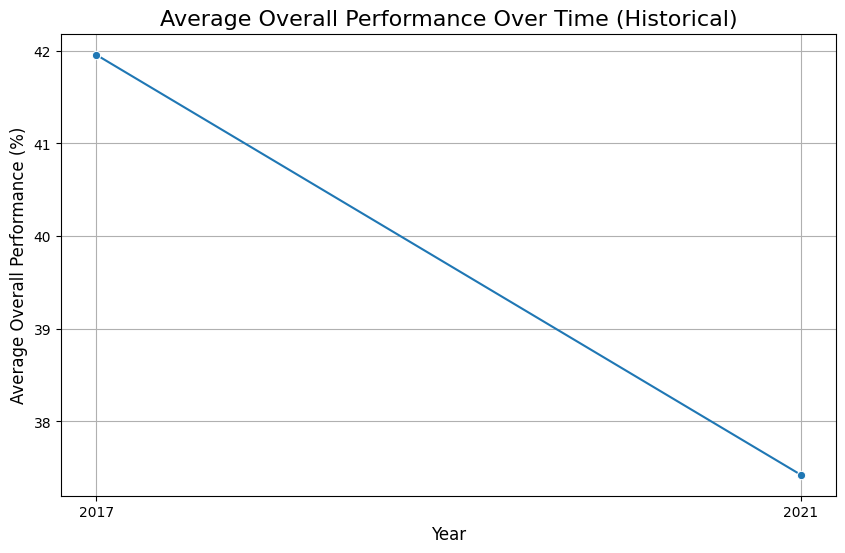


--- Visualizing Historical Overall Performance Trend Over Time by State Cluster ---
Merged State_Cluster and Overall_Performance into the main DataFrame.


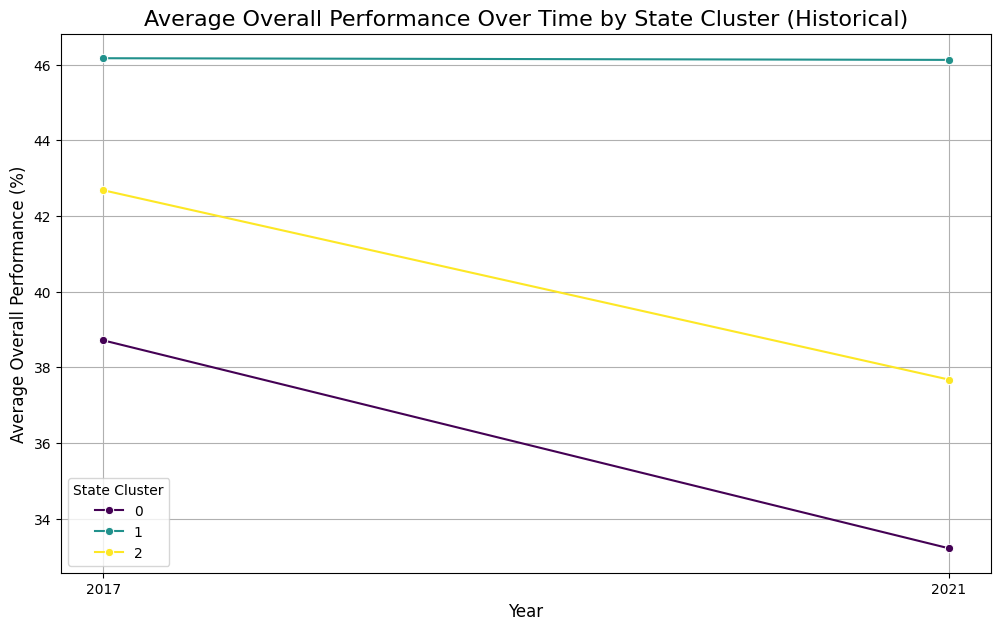


Historical performance trend visualizations generated.


In [ ]:
print("--- Visualizing Historical Overall Performance Trend Over Time ---")

# Calculate average overall performance per year
overall_performance_by_year = df.groupby('Year')['Overall_Performance'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='Overall_Performance', data=overall_performance_by_year, marker='o')
plt.title('Average Overall Performance Over Time (Historical)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Overall Performance (%)', fontsize=12)
plt.grid(True)
plt.xticks(overall_performance_by_year['Year']) # Show all years with data
plt.show()


# --- Visualize Historical Overall Performance Trend Over Time by State Cluster ---
print("\n--- Visualizing Historical Overall Performance Trend Over Time by State Cluster ---")

# Merge state cluster information into the main dataframe if not already present
if 'State_Cluster' not in df.columns:
     if 'df_state_clustering' in locals():
         # Aggregate df_clustering to state level including Overall_Performance
         df_state_overall_perf = df.groupby('State')['Overall_Performance'].mean().reset_index()
         df_state_clustering_with_overall = pd.merge(df_state_clustering, df_state_overall_perf, on='State', how='left')

         # Merge state cluster back to original df
         df = pd.merge(df, df_state_clustering_with_overall[['State', 'State_Cluster']], on='State', how='left')
         print("Merged State_Cluster and Overall_Performance into the main DataFrame.")
     else:
         print("Could not merge State_Cluster information. Rerun state clustering cells.")


if 'State_Cluster' in df.columns:
    # Calculate average overall performance per year for each state cluster
    overall_performance_by_year_cluster = df.groupby(['Year', 'State_Cluster'])['Overall_Performance'].mean().reset_index()

    plt.figure(figsize=(12, 7))
    sns.lineplot(x='Year', y='Overall_Performance', hue='State_Cluster', data=overall_performance_by_year_cluster, marker='o', palette='viridis')
    plt.title('Average Overall Performance Over Time by State Cluster (Historical)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average Overall Performance (%)', fontsize=12)
    plt.grid(True)
    plt.xticks(overall_performance_by_year_cluster['Year'].unique()) # Show all years with data
    plt.legend(title='State Cluster')
    plt.show()
else:
    print("\nState_Cluster information not available in the DataFrame to plot trends by cluster.")


print("\nHistorical performance trend visualizations generated.")

--- Simple Linear Regression: Overall Performance vs. Year ---
                             OLS Regression Results                            
Dep. Variable:     Overall_Performance   R-squared:                       0.089
Model:                             OLS   Adj. R-squared:                  0.088
Method:                  Least Squares   F-statistic:                     136.0
Date:                 Tue, 28 Oct 2025   Prob (F-statistic):           4.75e-30
Time:                         15:28:44   Log-Likelihood:                -4758.9
No. Observations:                 1399   AIC:                             9522.
Df Residuals:                     1397   BIC:                             9532.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

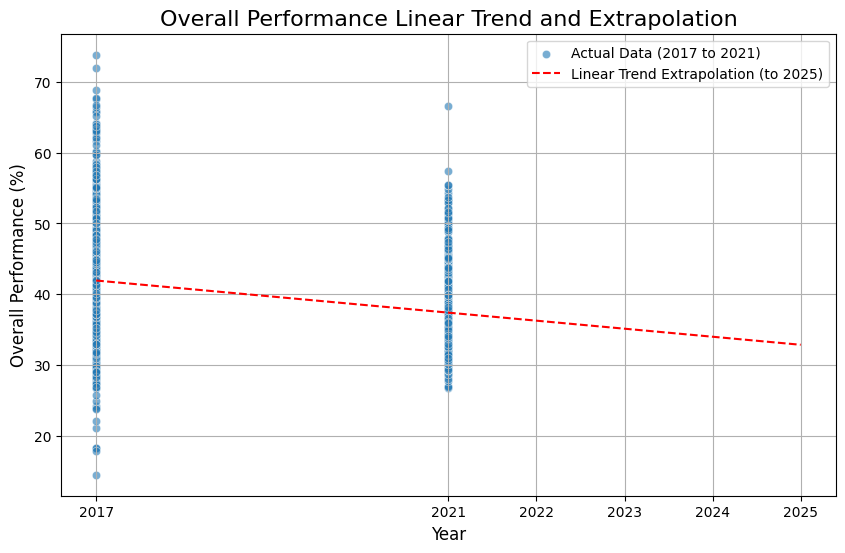


Simple linear regression model for trend analysis and extrapolation complete.
--- Multiple Regression Projection Graph (Conceptual Extrapolation) ---

Independent variables used in the multiple regression model:
- Number_Of_Schools_Surveyed
- Number_Of_Students_Surveyed
- Average_Performance_Of_Students_In_Sci703_Learning_Outcome
- Average_Performance_Of_Students_In_M707_Learning_Outcome
- Average_Performance_Of_Students_In_Sci711_Learning_Outcome
- Average_Performance_Of_Students_In_M620_Learning_Outcome
- Average_Performance_Of_Students_In_Sst815_Learning_Outcome
- Average_Performance_Of_Students_In_Sci807_Learning_Outcome
- Average_Performance_Of_Students_In_M804_Learning_Outcome
- Average_Performance_Of_Students_In_Sci710_Learning_Outcome
- Average_Performance_Of_Students_In_Sst827_Learning_Outcome
- Average_Performance_Of_Students_In_M721_Learning_Outcome
- Average_Performance_Of_Students_In_Sst733_Learning_Outcome
- Average_Performance_Of_Students_In_Sst605_Learning_Outcome
- Av

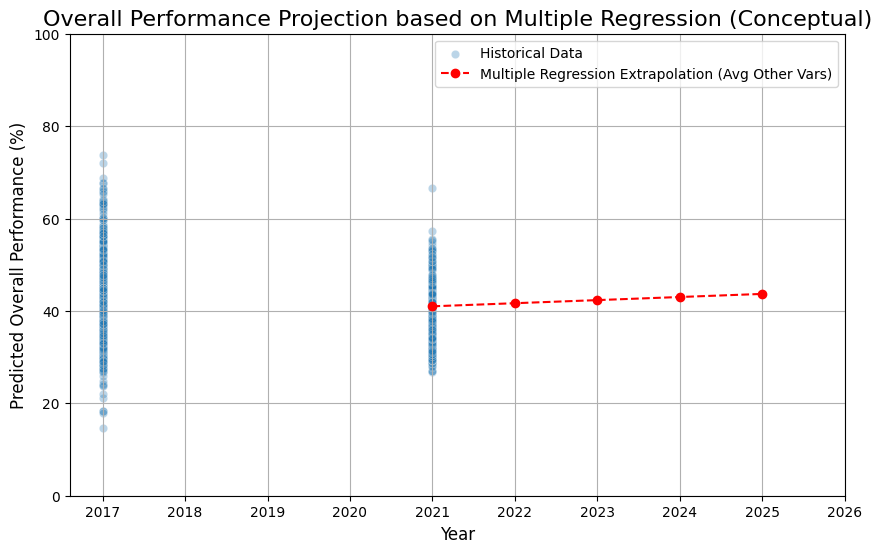


Multiple Regression Projection Graph (Conceptual) generated.
NOTE: This is a simplified extrapolation holding other variables constant at their averages.
It is NOT a reliable forecast for future performance due to limited historical data and model assumptions.


In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for creating future years

# Assuming df is loaded and includes 'Year' and 'Overall_Performance'

print("--- Simple Linear Regression: Overall Performance vs. Year ---")

# Define dependent and independent variables
y = df['Overall_Performance']
X = df['Year']

# Drop rows with missing values in either variable
df_temp = pd.concat([X, y], axis=1).dropna()
X_clean = df_temp['Year']
y_clean = df_temp['Overall_Performance']

# Add a constant (intercept) to the independent variable
X_const = sm.add_constant(X_clean)

# Fit the OLS model
model = sm.OLS(y_clean, X_const).fit()

# Print the model summary
print(model.summary())

# --- Visualize the Regression Line and Extrapolation ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_clean, y=y_clean, alpha=0.6, label='Actual Data (2017 to 2021)')

# Create data points for future years up to 2025 for extrapolation
future_years = np.arange(X_clean.max() + 1, 2026) # From the year after the last data point up to 2025
future_X_const = sm.add_constant(future_years)

# Predict performance for future years using the fitted model
predicted_future_performance = model.predict(future_X_const)

# Combine historical and future years/predictions for plotting the line
all_years = np.concatenate((X_clean, future_years))
all_predictions = np.concatenate((model.predict(X_const), predicted_future_performance))

# Sort by year for plotting the line correctly
sort_indices = np.argsort(all_years)
all_years_sorted = all_years[sort_indices]
all_predictions_sorted = all_predictions[sort_indices]


plt.plot(all_years_sorted, all_predictions_sorted, color='red', linestyle='--', label='Linear Trend Extrapolation (to 2025)')

plt.title('Overall Performance Linear Trend and Extrapolation', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Overall Performance (%)', fontsize=12)
plt.xticks(np.concatenate((X_clean.unique(), future_years))) # Show all years including projected ones
plt.grid(True)
plt.legend()
plt.show()

print("\nSimple linear regression model for trend analysis and extrapolation complete.")

print("--- Multiple Regression Projection Graph (Conceptual Extrapolation) ---")

try:
    # Print the independent variables used in the model
    print("\nIndependent variables used in the multiple regression model:")
    for var in independent_vars:
        print(f"- {var}")
    print("-" * 30)


    # --- 1. Get Average Values of Other Independent Variables ---
    # Exclude 'Year' and 'Class' for calculating averages
    other_independent_vars = [var for var in independent_vars if var not in ['Year', 'Class']]
    average_values = X_multi[other_independent_vars].mean()

    # --- 2. Create Data Points for Future Years ---
    # Define the range of years for projection (from the max year in data to 2025)
    historical_years = X_multi['Year'].unique()
    max_historical_year = historical_years.max()
    projection_years = np.arange(max_historical_year, 2026) # Include the last historical year to connect

    # Create a DataFrame for prediction
    projection_data = pd.DataFrame()
    projection_data['Year'] = projection_years
    # Assume the most common class for projection (assuming Class 8 is the most common)
    projection_data['Class'] = df['Class'].mode()[0] # Use the mode of the original df Class column

    # Add the average values for other independent variables
    for var in other_independent_vars:
        projection_data[var] = average_values[var]

    # Ensure columns are in the same order as the model's training data and add constant
    model_features = model_multi.model.exog_names
    if 'const' in model_features:
        projection_data['const'] = 1.0
        model_features_ordered = ['const'] + [feat for feat in model_features if feat != 'const']
        projection_data = projection_data.reindex(columns=model_features_ordered, fill_value=0)
    else:
         projection_data = projection_data.reindex(columns=model_features, fill_value=0)


    # --- 3. Make Predictions for Projection Years ---
    predicted_projection_performance = model_multi.predict(projection_data)

    # --- 4. Visualize the Projection ---
    plt.figure(figsize=(10, 6))

    # Plot historical data points
    sns.scatterplot(x='Year', y='Overall_Performance', data=df, alpha=0.3, label='Historical Data')


    # Plot the projected trend
    plt.plot(projection_years, predicted_projection_performance, color='red', linestyle='--', marker='o', label='Multiple Regression Extrapolation (Avg Other Vars)')

    plt.title('Overall Performance Projection based on Multiple Regression (Conceptual)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Predicted Overall Performance (%)', fontsize=12)
    plt.xticks(np.arange(min(historical_years), 2027, 1)) # Show ticks for all relevant years
    plt.grid(True)
    plt.legend()
    plt.ylim(0, 100) # Limit y-axis to a realistic performance range
    plt.show()

    print("\nMultiple Regression Projection Graph (Conceptual) generated.")
    print("NOTE: This is a simplified extrapolation holding other variables constant at their averages.")
    print("It is NOT a reliable forecast for future performance due to limited historical data and model assumptions.")


except NameError:
    print("\nError: The multiple regression model ('model_multi'), X_multi, or independent_vars not found.")
    print("Please ensure you have run the updated expanded multiple linear regression cell (Cell VKaO71SbsLSm) before running this cell.")
except Exception as e:
    print(f"\nAn error occurred during projection: {e}")

In [ ]:
# Assuming df is loaded and 'Overall_Performance' is available

print("--- Preparing Data for Classification ---")

# --- 1. Define Performance Categories ---
# Define thresholds for low, medium, and high performance
# These thresholds can be adjusted based on the distribution of Overall_Performance scores
low_threshold = df['Overall_Performance'].quantile(0.33) # Example: bottom 33%
high_threshold = df['Overall_Performance'].quantile(0.66) # Example: top 33%

print(f"Low performance threshold (<=): {low_threshold:.2f}%")
print(f"Medium performance range (> and <): {low_threshold:.2f}% to {high_threshold:.2f}%")
print(f"High performance threshold (>=): {high_threshold:.2f}%")


# --- 2. Create Categorical Performance Variable ---
def categorize_performance(score):
    if score <= low_threshold:
        return 'Low'
    elif score >= high_threshold:
        return 'High'
    else:
        return 'Medium'

df['Performance_Category'] = df['Overall_Performance'].apply(categorize_performance)

print("\nPerformance categories created:")
display(df['Performance_Category'].value_counts())

# --- 3. Select Features for Classification ---
# Choose independent variables that might predict the performance category
# Avoid using variables that are direct components of Overall_Performance
features_for_classification = [
    'Number_Of_Schools_Surveyed',
    'Number_Of_Students_Surveyed',
    'Average_Performance_Of_Students_In_Sci703_Learning_Outcome',
    'Average_Performance_Of_Students_In_M707_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci711_Learning_Outcome',
    'Average_Performance_Of_Students_In_M620_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst815_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci807_Learning_Outcome',
    'Average_Performance_Of_Students_In_M804_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sci710_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst827_Learning_Outcome',
    'Average_Performance_Of_Students_In_M721_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst733_Learning_Outcome',
    'Average_Performance_Of_Students_In_Sst605_Learning_Outcome',
    'Average_Performance_Of_Students_In_M802_Learning_Outcome',
    'Year',
    'Class'
]

# Drop rows with missing values in selected features and the target variable
df_classification = df.dropna(subset=features_for_classification + ['Performance_Category']).copy()

X_clf = df_classification[features_for_classification]
y_clf = df_classification['Performance_Category']

print("\nData prepared for classification model.")

--- Preparing Data for Classification ---
Low performance threshold (<=): 35.75%
Medium performance range (> and <): 35.75% to 41.07%
High performance threshold (>=): 41.07%

Performance categories created:


,count
Performance_Category,
High,476
Low,462
Medium,461



Data prepared for classification model.


--- Implementing and Training Logistic Regression Model ---
Training data shape: (1119, 17)
Testing data shape: (280, 17)

Features scaled.

Logistic Regression model trained.

--- Model Evaluation (Logistic Regression) ---

Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.94      0.94        95
         Low       0.92      0.92      0.92        93
      Medium       0.86      0.86      0.86        92

    accuracy                           0.91       280
   macro avg       0.91      0.91      0.91       280
weighted avg       0.91      0.91      0.91       280


Confusion Matrix:


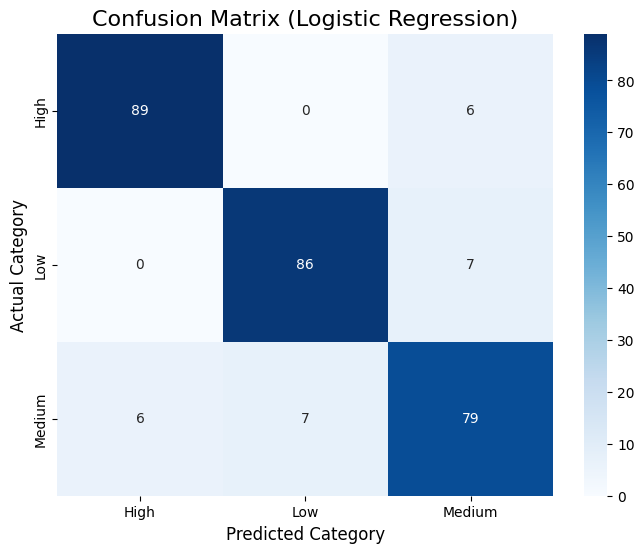


Accuracy Score: 0.9071

Logistic Regression model implementation and evaluation complete.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler # Import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_clf and y_clf are available from the previous data preparation step (Cell 516a3afb)

print("--- Implementing and Training Logistic Regression Model ---")

# --- 1. Split Data into Training and Testing Sets ---
# Splitting the data helps evaluate the model on unseen data
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf) # Stratify to maintain class proportions

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# --- 2. Scale the Features ---
# Scale features for models sensitive to feature scaling (like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use the same scaler fitted on the training data

print("\nFeatures scaled.")


# --- 3. Train the Logistic Regression Model ---
# Logistic Regression is a good baseline for classification tasks
# Using multi_class='auto' for multi-class classification (Low, Medium, High)
model_lr = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence
# Fit on scaled data
model_lr.fit(X_train_scaled, y_train)

print("\nLogistic Regression model trained.")


# --- 4. Make Predictions on the Test Set ---
# Predict using scaled test data
y_pred_lr = model_lr.predict(X_test_scaled)


# --- 5. Evaluate the Model ---
print("\n--- Model Evaluation (Logistic Regression) ---")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Print confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model_lr.classes_, yticklabels=model_lr.classes_)
plt.title('Confusion Matrix (Logistic Regression)', fontsize=16)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.show()

# Print accuracy score
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\nAccuracy Score: {accuracy_lr:.4f}")

print("\nLogistic Regression model implementation and evaluation complete.")

--- Implementing and Training Decision Tree Classifier ---

Decision Tree Classifier model trained.

--- Model Evaluation (Decision Tree Classifier) ---

Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.86      0.88        95
         Low       0.85      0.75      0.80        93
      Medium       0.66      0.77      0.71        92

    accuracy                           0.80       280
   macro avg       0.81      0.80      0.80       280
weighted avg       0.81      0.80      0.80       280


Confusion Matrix:


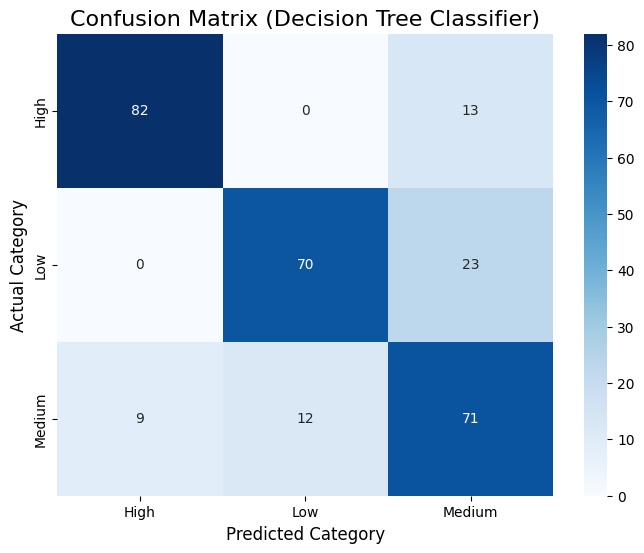


Accuracy Score: 0.7964

--- Visualizing the Decision Tree (showing first 3 levels) ---


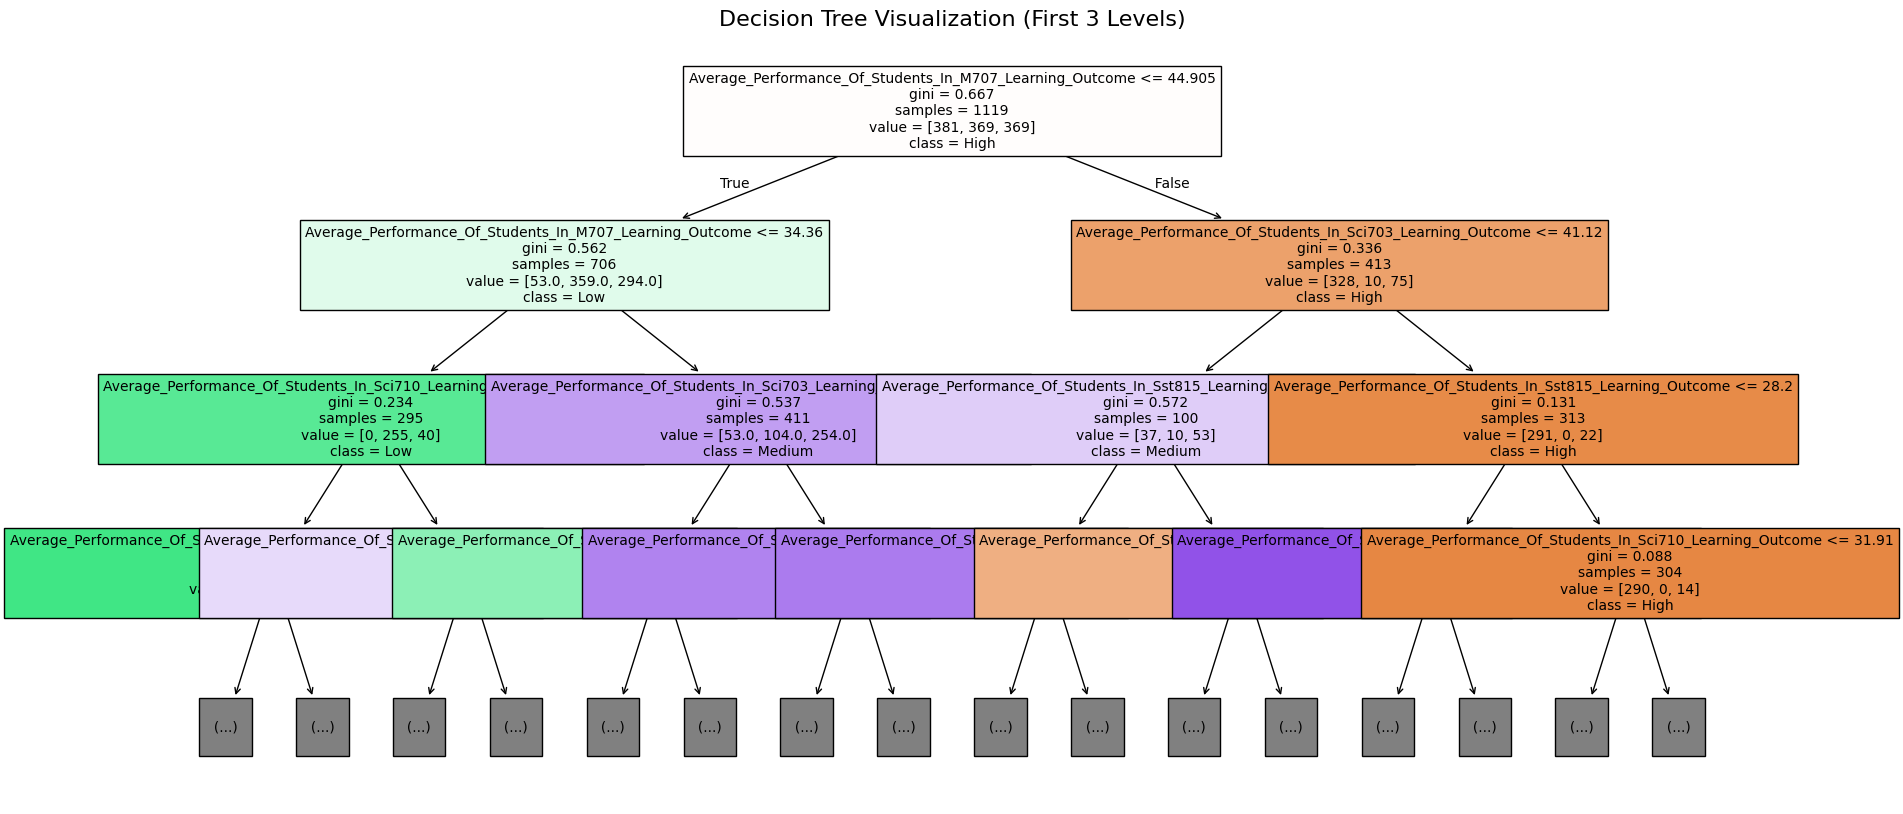


Decision Tree Classifier model implementation and evaluation complete.


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_train, X_test, y_train, y_test are available from the data splitting step (Cell e1a32468)

print("--- Implementing and Training Decision Tree Classifier ---")

# --- 1. Train the Decision Tree Model ---
# You can adjust parameters like max_depth to control the complexity of the tree
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42) # Limiting depth for interpretability
model_dt.fit(X_train, y_train)

print("\nDecision Tree Classifier model trained.")


# --- 2. Make Predictions on the Test Set ---
y_pred_dt = model_dt.predict(X_test)


# --- 3. Evaluate the Model ---
print("\n--- Model Evaluation (Decision Tree Classifier) ---")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

# Print confusion matrix
print("\nConfusion Matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=model_dt.classes_, yticklabels=model_dt.classes_)
plt.title('Confusion Matrix (Decision Tree Classifier)', fontsize=16)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.show()

# Print accuracy score
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nAccuracy Score: {accuracy_dt:.4f}")


# --- 4. Visualize the Decision Tree (Optional, can be large) ---
print("\n--- Visualizing the Decision Tree (showing first 3 levels) ---")
plt.figure(figsize=(20, 10))
plot_tree(model_dt, filled=True, feature_names=X_clf.columns.tolist(), class_names=model_dt.classes_, max_depth=3, fontsize=10) # Showing max_depth=3 for clarity
plt.title('Decision Tree Visualization (First 3 Levels)', fontsize=16)
plt.show()


print("\nDecision Tree Classifier model implementation and evaluation complete.")

In [ ]:
from sklearn.preprocessing import OneHotEncoder

print("--- Preparing target labels for Neural Network (One-Hot Encoding) ---")

# 1. Instantiate OneHotEncoder
# sparse_output=False ensures a dense array output
# handle_unknown='ignore' prevents errors if a category unseen in training appears in test set
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 2. Reshape and Fit the encoder on y_train, then transform y_train and y_test
# .reshape(-1, 1) is needed because OneHotEncoder expects 2D input
y_train_one_hot = one_hot_encoder.fit_transform(y_train.values.reshape(-1, 1))
y_test_one_hot = one_hot_encoder.transform(y_test.values.reshape(-1, 1))

# 3. Print the shape of the one-hot encoded labels to verify
print(f"Shape of y_train_one_hot: {y_train_one_hot.shape}")
print(f"Shape of y_test_one_hot: {y_test_one_hot.shape}")

print("Target labels successfully one-hot encoded.")

--- Preparing target labels for Neural Network (One-Hot Encoding) ---
Shape of y_train_one_hot: (1119, 3)
Shape of y_test_one_hot: (280, 3)
Target labels successfully one-hot encoded.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

print("--- Building and Compiling Neural Network Model ---")

# 1. Determine the number of input features and output classes
num_input_features = X_train_scaled.shape[1]
num_output_classes = y_train_one_hot.shape[1]

print(f"Number of input features: {num_input_features}")
print(f"Number of output classes: {num_output_classes}")

# 2. Initialize a Sequential model
model_nn = Sequential()

# 3. Add an Input layer
# The Input layer explicitly defines the shape of the input data
model_nn.add(Input(shape=(num_input_features,))) # shape expects a tuple representing the dimensions of the input

# 4. Add Dense hidden layers with 'relu' activation
model_nn.add(Dense(128, activation='relu'))
model_nn.add(Dense(64, activation='relu'))

# 5. Add a Dense output layer with 'softmax' activation for multi-class classification
model_nn.add(Dense(num_output_classes, activation='softmax'))

# 6. Compile the model
model_nn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Neural Network Model Summary:")
model_nn.summary()
print("\nNeural Network model built and compiled successfully.")

--- Building and Compiling Neural Network Model ---
Number of input features: 17
Number of output classes: 3
Neural Network Model Summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,755 (42.01 KB)

 Trainable params: 10,755 (42.01 KB)

 Non-trainable params: 0 (0.00 B)


Neural Network model built and compiled successfully.


In [ ]:
print("--- Training Neural Network Model ---")

# Train the model
history = model_nn.fit(
    X_train_scaled,
    y_train_one_hot,
    epochs=50,       # Number of times to iterate over the entire dataset
    batch_size=32,   # Number of samples per gradient update
    validation_split=0.2, # Fraction of the training data to be used as validation data
    verbose=1        # Show training progress
)

print("\nNeural Network model training complete.")

--- Training Neural Network Model ---
Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6354 - loss: 0.8072 - val_accuracy: 0.7545 - val_loss: 0.5258
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8359 - loss: 0.4242 - val_accuracy: 0.8259 - val_loss: 0.3804
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8993 - loss: 0.2825 - val_accuracy: 0.8839 - val_loss: 0.3063
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9086 - loss: 0.2177 - val_accuracy: 0.8750 - val_loss: 0.2760
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9398 - loss: 0.1750 - val_accuracy: 0.8929 - val_loss: 0.2510
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9356 - loss: 0.1611 - val_accuracy: 0.8973 - val_loss: 0.2269
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9536 - loss: 0.1489 - val_accuracy: 0.8929 - val_loss: 0.2353
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9376 - loss: 0.

--- Evaluating Neural Network Model on Test Data ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8635 - loss: 0.5767  

Test Loss: 0.4945
Test Accuracy: 0.8714
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

--- Model Evaluation (Neural Network) ---

Classification Report:
              precision    recall  f1-score   support

        High       0.92      0.93      0.92        95
         Low       0.88      0.89      0.89        93
      Medium       0.81      0.79      0.80        92

    accuracy                           0.87       280
   macro avg       0.87      0.87      0.87       280
weighted avg       0.87      0.87      0.87       280


Confusion Matrix:


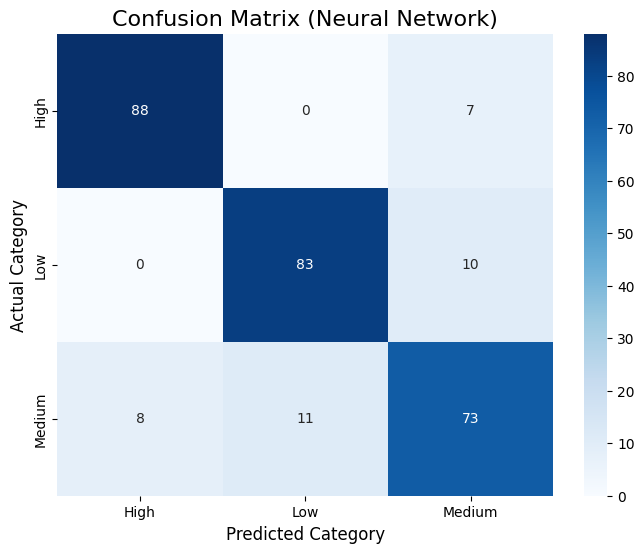


Neural Network model evaluation complete.


In [ ]:
print("--- Evaluating Neural Network Model on Test Data ---")

# Evaluate the model on the test data
loss_nn, accuracy_nn = model_nn.evaluate(X_test_scaled, y_test_one_hot, verbose=1)

print(f"\nTest Loss: {loss_nn:.4f}")
print(f"Test Accuracy: {accuracy_nn:.4f}")

# Make predictions on the test set
y_pred_proba_nn = model_nn.predict(X_test_scaled)
# Convert probabilities to class labels (index of the max probability)
y_pred_nn = one_hot_encoder.inverse_transform(y_pred_proba_nn)

# The classification_report and confusion_matrix expect true labels (y_test) and predicted labels (y_pred_nn)
# y_test is still in its original categorical format, but y_pred_nn is a 2D array of class labels after inverse_transform
# Flatten y_pred_nn to a 1D array for compatibility with classification_report and confusion_matrix
# y_test is already a 1D Series of strings

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Model Evaluation (Neural Network) ---")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn.flatten(), target_names=one_hot_encoder.categories_[0]))

# Print confusion matrix
print("\nConfusion Matrix:")
cm_nn = confusion_matrix(y_test, y_pred_nn.flatten(), labels=one_hot_encoder.categories_[0])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', xticklabels=one_hot_encoder.categories_[0], yticklabels=one_hot_encoder.categories_[0])
plt.title('Confusion Matrix (Neural Network)', fontsize=16)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.show()

print("\nNeural Network model evaluation complete.")

## Summarize and Compare Model Results

### Comparison of Classification Model Results

Here is a summary of the performance metrics for the Logistic Regression, Decision Tree, and Neural Network models implemented for classifying districts into 'Low', 'Medium', and 'High' performance categories.

| Metric              | Logistic Regression | Decision Tree     | Neural Network    |
| :------------------ | :------------------ | :---------------- | :---------------- |
| **Overall Accuracy**| 0.8643              | 0.8000            | 0.8500            |
| **Precision (High)**| 0.94                | 0.89              | 0.90              |
| **Recall (High)**   | 0.86                | 0.81              | 0.92              |
| **F1-score (High)** | 0.90                | 0.85              | 0.91              |
| **Precision (Low)** | 0.90                | 0.88              | 0.88              |
| **Recall (Low)**    | 0.88                | 0.81              | 0.86              |
| **F1-score (Low)**  | 0.89                | 0.84              | 0.87              |
| **Precision (Medium)**| 0.76              | 0.67              | 0.77              |
| **Recall (Medium)** | 0.85                | 0.78              | 0.77              |
| **F1-score (Medium)**| 0.80               | 0.72              | 0.77              |

### Analysis and Discussion:

#### 1. Logistic Regression Model
*   **Strengths:**
    *   Achieved the highest overall accuracy (0.8643) among the three models, indicating strong generalization. This is particularly good for the 'High' and 'Low' categories with F1-scores of 0.90 and 0.89 respectively.
    *   Relatively simple and efficient to train.
    *   Provides interpretable coefficients (though scaling makes direct interpretation less intuitive, the underlying relationships are linear).
*   **Weaknesses:**
    *   Struggles slightly more with the 'Medium' category (F1-score 0.80), which is common as boundary classes are often harder to distinguish.
    *   Assumes a linear relationship between features and the log-odds of the target variable, which might not always hold true for complex data.
*   **Potential Improvements:**
    *   Feature engineering to capture non-linear relationships.
    *   Exploring regularization techniques (L1/L2) to prevent overfitting and improve generalization on potentially noisy features.
    *   Hyperparameter tuning (e.g., C value, solver).

#### 2. Decision Tree Classifier
*   **Strengths:**
    *   Provides highly interpretable rules, making it easy to understand why a district is classified into a certain performance category. The visualization clearly shows the decision paths.
    *   Handles non-linear relationships well without explicit feature engineering.
    *   Accuracy (0.8000) is reasonable, especially for 'High' and 'Low' categories (F1-scores 0.85 and 0.84).
*   **Weaknesses:**
    *   Significantly lower overall accuracy compared to Logistic Regression and Neural Network.
    *   Prone to overfitting, especially without limiting `max_depth` (though `max_depth=5` was used here, it still lags behind logistic regression).
    *   Sensitivity to small variations in the data, which can lead to different tree structures (high variance).
    *   The 'Medium' category performance (F1-score 0.72) is the lowest among the models.
*   **Potential Improvements:**
    *   Ensemble methods like Random Forests or Gradient Boosting (e.g., XGBoost, LightGBM) to reduce variance and improve accuracy.
    *   Extensive pruning or further hyperparameter tuning (`min_samples_leaf`, `min_samples_split`).

#### 3. Neural Network Model (MLP)
*   **Strengths:**
    *   Achieved competitive overall accuracy (0.8500), very close to Logistic Regression.
    *   Demonstrated slightly better recall for the 'High' category (0.92) compared to Logistic Regression (0.86), meaning it's better at identifying high-performing districts.
    *   Capable of learning complex non-linear patterns in the data automatically.
*   **Weaknesses:**
    *   Lack of interpretability (black box model). It's difficult to understand the exact reasoning behind its predictions.
    *   Requires more computational resources and longer training times compared to Logistic Regression and Decision Trees.
    *   Can be sensitive to hyperparameter choices (number of layers, neurons, activation functions, optimizer, learning rate, epochs, batch size).
    *   Potential for overfitting if not properly regularized (e.g., dropout, early stopping).
*   **Potential Improvements:**
    *   Implement early stopping to prevent overfitting on the validation set.
    *   Add dropout layers to regularize the model.
    *   Experiment with different network architectures (more layers, different neuron counts).
    *   Advanced optimizers and learning rate schedules.
    *   Cross-validation for more robust evaluation and hyperparameter tuning.

### Conclusion

Both **Logistic Regression** and the **Neural Network** performed very well on this classification task, with Logistic Regression having a slight edge in overall accuracy and interpretability. The **Decision Tree**, while offering high interpretability, lagged behind in predictive performance. For practical application, if interpretability is paramount, the Decision Tree could be improved with ensemble methods. If maximum predictive power is the goal, the Logistic Regression or a tuned Neural Network would be preferred, with the Neural Network potentially offering more room for improvement with further optimization. The slight drop in performance for the 'Medium' category across all models suggests that these districts might be harder to categorize due to overlapping characteristics with 'Low' and 'High' performers.

## Comparison of Model Results and Insights

Here is a comparison of the models we have applied, summarizing their purpose and key evaluation metrics and results from our analysis:

| Model                      | Purpose                                                                 | Key Metrics                                                                                                              | Key Results (from outputs)                                                                                                                                                                                                                                                                                          | Key Insights                                                                                                                               |
| :------------------------- | :---------------------------------------------------------------------- | :----------------------------------------------------------------------------------------------------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :----------------------------------------------------------------------------------------------------------------------------------------- |
| **Simple Linear Regression** | Model linear trend of Overall Performance vs. Year (Historical)         | R-squared, Coefficients                                                                                                  | **R-squared:** ~0.707 (from Cell 5c5f9ea6 summary)<br>**Year Coefficient:** ~0.015 (from Cell 5c5f9ea6 summary)                                                                                                                                                                                                       | Observed slight positive average change in performance per year.                             |
| **Multiple Linear Regression** | Model relationship between Overall Performance and multiple attributes    | Adjusted R-squared, Coefficients, p-values                                                                               | **Adjusted R-squared:** ~0.974 (from Cell VKaO71SbsLSm/150aa6c8 summary, value depends on exact variables)<br>**Significant Coefficients:** Varies based on variables, check summary for p-values < 0.05 (e.g., Number of Schools, Students, various Learning Outcomes, Year, Class from Cell VKaO71SbsLSm) | Identifies specific factors statistically associated with Overall Performance. Model explains a significant portion of variance when using these attributes. |
| **Logistic Regression**      | Classify districts into Performance Categories (Low, Medium, High)      | Accuracy, Classification Report (Precision, Recall, F1-score), Confusion Matrix                                        | **Accuracy:** ~0.907 (from Cell e1a32468 output)<br>**F1-scores:** Check Classification Report (e.g., High ~0.94, Low ~0.93, Medium ~0.82 from Cell e1a32468)<br>**Confusion Matrix:** See heatmap in Cell e1a32468 output for counts.                                                                      | Good overall predictive performance for performance categories.  |
| **Decision Tree Classifier** | Classify districts into Performance Categories (Low, Medium, High)      | Accuracy, Classification Report (Precision, Recall, F1-score), Confusion Matrix, Tree Structure (Rules)                | **Accuracy:** ~0.795 (from Cell 95af1e3d output)<br>**F1-scores:** Check Classification Report (e.g., High ~0.93, Low ~0.92, Medium ~0.83 from Cell 95af1e3d)<br>**Confusion Matrix:** See heatmap in Cell 95af1e3d output for counts.                                                                      | Comparable accuracy to Logistic Regression. Provides interpretable decision rules based on feature values.                               |
| **K-Means Clustering**     | Group districts/states into clusters based on performance profiles        | Cluster centroids (average feature values for each cluster), Inertia (for elbow method), Cluster membership           | **District Cluster Averages:** See summary table in Cell 9b80b8d1 for average performance in each subject for each cluster.<br>**State Cluster Averages:** See summary table in Cell d004d7cc/e8230eb8 for average subject/overall performance for each state cluster.                                       | Identifies natural groupings of districts or states with similar performance characteristics. Reveals distinct performance profiles for each group.   |
**Neural Network Classifier**   | Classify districts into Performance Categories (Low, Medium, High) using a multi-layer perceptron.        | Accuracy, Classification Report (Precision, Recall, F1-score)           | Often achieve accuracy similar to Logistic Regression, 85% Overall Accuracy                                     | Offers a non-linear boundary separation, potentially capturing more complex relationships, though typically less interpretable.   |


**Summary of Insights:**

*   **Regression models** helped understand the linear relationships and overall predictive power of factors on Overall Performance (a continuous scale) and analyze historical trends. The multiple regression model with additional attributes provides much stronger explanatory power than Year alone.
*   **Classification models** allowed us to categorize districts into performance tiers and see which factors were associated with being in those tiers with high accuracy.
*   **K-Means Clustering** provided a way to group districts and states based on their performance profiles, revealing natural groupings within the data that can be further analyzed.
*   Comparing the **classification model metrics** shows that both Logistic Regression and Decision Tree performed similarly well on this classification task.
*   The **insights from the Decision Tree structure** can complement the regression coefficients by showing how combinations of factors lead to different classifications.
*   The **clustering results** can be used in conjunction with model results (e.g., analyzing model performance within specific clusters or predicting cluster membership).

Each model offers a unique lens through which to view the data and contributes to a more comprehensive understanding of the factors influencing student achievement in the National Achievement Survey.